# Begin

Generalization of 18b and 18c - single notebook to both reconstruct and predict. Utilizes findings and experiences of both

In [100]:
# @launchit.collected
# @launchit.collected_temp_config
# @launchit.collected_optuna
# @launchit.collected_initrd
# @launchit.collected_build_docker_launch

In [101]:
# @launchit.collected_manual_run_docker_launch
# @launchit.collected_optuna_run_docker_launch

In [102]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import gzip
from functools import lru_cache
import piq

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import ale_py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.nn.attention import SDPBackend, sdpa_kernel

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement

# Init

In [103]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [104]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True)    
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache_fname, artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache_fname=None, 
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        CONFIG = CONFIG._replace(artifact_registry_cache_fname=os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl'))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [105]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [106]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18d_world_model_01',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18d_world_model_01.ipynb',
 'self_name': '18d_world_model_01',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18d_world_model_01.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [107]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN = auto()
    WORKER = auto()

LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    # Launch
    launch_goal: LaunchGoal = lu.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED)
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class System:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False
        use_amp: bool = True

    @dataclass(slots=True)
    class Dataset:
        train: list = None # list of IDs of dataset used for training
        test: str = None # ID of a dataset used for test
        
    @dataclass(slots=True)
    class Model:
        parent: str = None
        is_reconstruction: bool = True 
        is_prediction: bool = True
        sequence_length: int = 4
        ob_shape: tuple = (1, 178, 152)
        ob_vision_head: dict = None  # dict with params: grid, features_counts
        actions_count: int = 6
        g_encoding: dict = None  # dict with params: is_common
        d_model: int = 256
        layers_count: int = 3
        heads_count: int = 4
        render_heads_count: int = 4 # number of parallel RenderHeads which could render various parts of final image (a-la composition)
        attention_backend: str = 'MATH' # value of SDPBackend enum (getattr(SDPBackend, attention_backend))

    @dataclass(slots=True)
    class Train:
        epochs_count: int = 1 
        batch_size: int = 32
        optimizer: str = 'AdamW'
        max_grad_norm: float = 1.0
        learn_rate: str = 'const(0.00025)'
        bce_loss_coef: str = 'const(1.0)'
        edge_loss_coef: str = 'const(1.0)'

    system: System = dataclasses.field(default_factory=System)
    dataset: Dataset = dataclasses.field(default_factory=Dataset)
    model: Model = dataclasses.field(default_factory=Model)
    train: Train = dataclasses.field(default_factory=Train)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.system = Hyperparameters.System(**hp.system)
        hp.dataset = Hyperparameters.Dataset(**hp.dataset)
        hp.model = Hyperparameters.Model(**hp.model)
        hp.train = Hyperparameters.Train(**hp.train)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Runtime

## Runtime

In [108]:
@dataclass(slots=True)
class Runtime:
    mp_ctx: object = None
    optuna_trial: dict = None
    artifact_registry_cache: dict = None
    artifact_registry: object = None
    summary_writer: object = None
    world_model: object = None
    dataset_module: object = None
    train_datasets: dict = None
    test_dataset_fname: str = None
    render_test_batch: object = None
    pov_coord_lists: object = None

## Configure

In [109]:
# @launchit.disable
# @launchit.collect
import random
HP.system.comment = None
HP.system.random_seed = random.randint(0, 100)
HP.system.is_torch_deterministic = True
HP.system.is_torch_compile = False
HP.system.use_amp = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 9,
            'is_torch_deterministic': True,
            'is_torch_compile': False,
            'use_amp': True},
 'dataset': {'train': None, 'test': None},
 'model': {'parent': None,
           'is_reconstruction': True,
           'is_prediction': True,
           'sequence_length': 4,
           'ob_shape': (1, 178, 152),
           'ob_vision_head': None,
           'actions_count': 6,
           'g_encoding': None,
           'd_model': 256,
           'layers_count': 3,
           'heads_count': 4,
           'render_heads_count': 4,
           'attention_backend': 'MATH'},
 'train': {'epochs_count': 1,
           'batch_size': 32,
           'optimizer': 'AdamW',
           'max_grad_norm': 1.0,
           'learn_rate': 'const(0.00025)',
           'bce_loss_coef': 'const(1.0)',
           'edge_loss_coef': 'const(1.0)'}}


## Create

In [110]:
assert type(CONFIG).__name__ == 'Config', 'Runtime should be created for full-fledged Config instance only'
RT = Runtime()
RT.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.system.random_seed is not None:
    random.seed(HP.system.random_seed)
    torch.manual_seed(HP.system.random_seed)
    RNG = np.random.default_rng(HP.system.random_seed)    
    LOG(f'Random seed={HP.system.random_seed}')

if HP.system.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()

artifact_registry_type = os.environ.get('ARTIFACT_REGISTRY', '').upper()

if not artifact_registry_type:
    artifact_registry_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'NEXUS')

match artifact_registry_type:
    case 'NEXUS':
        kwargs = {}

        if os.environ.get('NEXUS_URL', None) is not None:
            kwargs['nexus_url'] = os.environ['NEXUS_URL']

        if os.environ.get('DOWNLOAD_NEXUS_URL', None) is not None:
            kwargs['download_nexus_url'] = os.environ['DOWNLOAD_NEXUS_URL']
        
        RT.artifact_registry = ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'Created ArtifactRegistry')
    case 'S3':
        kwargs = {}
        artifact_registry_cache_fname = os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl')
        
        if os.path.exists(artifact_registry_cache_fname):
            with open(artifact_registry_cache_fname, 'rb') as f:
                RT.artifact_registry_cache = pickle.load(f)
                assert isinstance(RT.artifact_registry_cache, dict)
                LOG(f'Artifact registry cache loaded from "{artifact_registry_cache_fname}"')
        
            kwargs['cache'] = RT.artifact_registry_cache
        else:
            LOG(f'Artifact registry cache "{artifact_registry_cache_fname}" is absent, nothing to load')
        
        RT.artifact_registry = S3ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'Created S3ArtifactRegistry')
    case _:
        assert False, f'Unsupported {artifact_registry_type=}'

if lc.version != 0:
    assert CONFIG.exec_mode != ExecMode.MASTER_NOTEBOOK, 'With MASTER_NOTEBOOK exec_mode one should not overwrite any of the launches (experiments)'
    RT.artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    meta = dict(
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)
else:
    assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK, 'MASTER_NOTEBOOK exec_mode is for working on 0 (dummy) version only'

RT.optuna_trial = None
optuna_trial_fname = os.path.join(CONFIG.initrd_path, 'optuna_trial.json')

if os.path.exists(optuna_trial_fname):
    with open(os.path.join(optuna_trial_fname), 'rt') as f:
        RT.optuna_trial = json.load(f)
        assert 'trial_number' in RT.optuna_trial, RT.optuna_trial
        assert 'study_serial' in RT.optuna_trial, RT.optuna_trial
        assert 'study_name' in RT.optuna_trial, RT.optuna_trial

    LOG(f'Optuna trial loaded from "{optuna_trial_fname}": {RT.optuna_trial}')

summary_log_dir = lc.name

if RT.optuna_trial is not None:
    summary_log_dir = os.path.join(summary_log_dir, f'opt_{RT.optuna_trial['study_serial']}')
    
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')

summary_writer_type = os.environ.get('SUMMARY_WRITER', '').upper()

if not summary_writer_type:
    summary_writer_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'RMQ')

match summary_writer_type:
    case 'RMQ':
        kwargs = {}

        if os.environ.get('RMQ_CONNECTION_URL', None) is not None:
            kwargs['rmq_connection_url'] = os.environ['RMQ_CONNECTION_URL']

        RT.summary_writer = RmqSummaryWriter(log_dir=summary_log_dir, **kwargs)
        LOG(f'Created RmqSummaryWriter')
    case 'S3':
        RT.summary_writer = S3SummaryWriter(log_dir=summary_log_dir)
        LOG(f'Created S3SummaryWriter')
    case _:
        assert False, f'Unsupported {summary_writer_type=}'

RT.summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 0)
RT.summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 0)
RT.summary_writer.flush()

Random seed=9
torch.backends.cudnn.deterministic=True
Created ArtifactRegistry
Tensorboard run=18d_world_model_01/0
Created RmqSummaryWriter


# Dataset

## Configure

In [117]:
# @launchit.disable
# @launchit.collect
HP.dataset.train = [
    'train_dataset_seq_eq_8:300',
    'train_dataset_seq_eq_8:301',
    'train_dataset_seq_eq_8:302',
    'train_dataset_seq_eq_8:303',
    'train_dataset_seq_eq_8:304',
    'train_dataset_seq_eq_8:305',
    'train_dataset_seq_eq_8:306',
    'train_dataset_seq_eq_8:307',
    'train_dataset_seq_eq_8:308',
    'train_dataset_seq_eq_8:309',
]
HP.dataset.test = 'test_dataset_seq_eq_8:300'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 9,
            'is_torch_deterministic': True,
            'is_torch_compile': False,
            'use_amp': True},
 'dataset': {'train': ['train_dataset_seq_eq_8:300',
                       'train_dataset_seq_eq_8:301',
                       'train_dataset_seq_eq_8:302',
                       'train_dataset_seq_eq_8:303',
                       'train_dataset_seq_eq_8:304',
                       'train_dataset_seq_eq_8:305',
                       'train_dataset_seq_eq_8:306',
                       'train_dataset_seq_eq_8:307',
                       'train_dataset_seq_eq_8:308',
                       'train_dataset_seq_eq_8:309'],
             'test': 'test_dataset_seq_eq_8:300'},
 'model': {'parent': None,
           'is_reconstruction': True,
           'is_prediction': True,
           'sequence_length': 4,
           'ob_shape': (1, 178, 152),
  

## Create

In [118]:
DATASET_NOTEBOOK_FNAME = '18b_dataset_01.ipynb'
source_code = launchit.extract_source_code(DATASET_NOTEBOOK_FNAME, collect_inds=[None, 'export_dataset'])
RT.dataset_module = lu.make_module(f'dataset_notebook', source_code)
RT.dataset_module.CONFIG = CONFIG
RT.dataset_module.RNG = RNG
RT.dataset_module.LOG = LOG
sys.modules['__main__'].Dataset = RT.dataset_module.Dataset # Req-d for unpickling

In [119]:
def download_dataset(dataset_id):
    coords = hp_parse_artifact_source(dataset_id)
    downloaded_pkl_gz_fname = os.path.join(CONFIG.private_data_path, f'{coords.model_name}.{coords.model_version}.pkl.gz')
    
    if not os.path.exists(downloaded_pkl_gz_fname):
        pkl_gz = RT.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='gz', maven_group_id=coords.group_id)

        with open(downloaded_pkl_gz_fname, 'wb') as f:
            f.write(pkl_gz)
            LOG(f'"{dataset_id}" saved to "{downloaded_pkl_gz_fname}"')
    else:
        LOG(f'"{dataset_id}" is backed by "{downloaded_pkl_gz_fname}"')

    return downloaded_pkl_gz_fname

@lru_cache(maxsize=None)
def load_dataset(fname):
    with gzip.GzipFile(filename=fname, mode='rb') as gzip_file:
        dataset = pickle.load(gzip_file)
        return dataset

In [120]:
RT.train_datasets = {}

for train_dataset_id in HP.dataset.train:
    fname = download_dataset(train_dataset_id)
    load_dataset(fname)
    RT.train_datasets[train_dataset_id] = fname

"train_dataset_seq_eq_8:300" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.300.pkl.gz"
"train_dataset_seq_eq_8:301" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.301.pkl.gz"
"train_dataset_seq_eq_8:302" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.302.pkl.gz"
"train_dataset_seq_eq_8:303" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.303.pkl.gz"
"train_dataset_seq_eq_8:304" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.304.pkl.gz"
"train_dataset_seq_eq_8:305" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.305.pkl.gz"
"train_dataset_seq_eq_8:306" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.306.pkl.gz"
"train_dataset_seq_eq_8:307" saved to "/home/misha/dev/mine/neurolab/data/18_rl/train_dataset_seq_eq_8.307.pkl.gz"
"train_dataset_seq_eq_8:308" saved to "/home/misha/dev/mine/neurolab/data/18_rl/

In [121]:
RT.test_dataset_fname = download_dataset(HP.dataset.test)
test_dataset = load_dataset(RT.test_dataset_fname)
test_dataset.init_iteration(batches_count=1, is_shuffled=False)
test_batch = next(iter(test_dataset))
batch_mask = test_batch.pmasks.sum(axis=1) == 0
test_batch = test_batch._replace(
    pmasks=test_batch.pmasks[batch_mask],
    obs=test_batch.obs[batch_mask],
    actions=test_batch.actions[batch_mask],
    dones=test_batch.dones[batch_mask],
)
# inds = RNG.choice(np.arange(len(test_batch.obs)), 5, replace=False)
inds = torch.tensor([2663, 13832, 13338,  4460, 10181])
print(inds)
RT.render_test_batch = Dataset.Batch(
    pmasks=test_batch.pmasks[inds].to(CONFIG.cuda_device),
    obs=test_batch.obs[inds].to(CONFIG.cuda_device),
    actions=test_batch.actions[inds].to(CONFIG.cuda_device),
    dones=test_batch.dones[inds].to(CONFIG.cuda_device),
    env_inds=None,
    step_inds=None,
    b_inds=None,
)
del test_batch

"test_dataset_seq_eq_8:300" saved to "/home/misha/dev/mine/neurolab/data/18_rl/test_dataset_seq_eq_8.300.pkl.gz"
tensor([ 2663, 13832, 13338,  4460, 10181])


## Verify render_test_batch

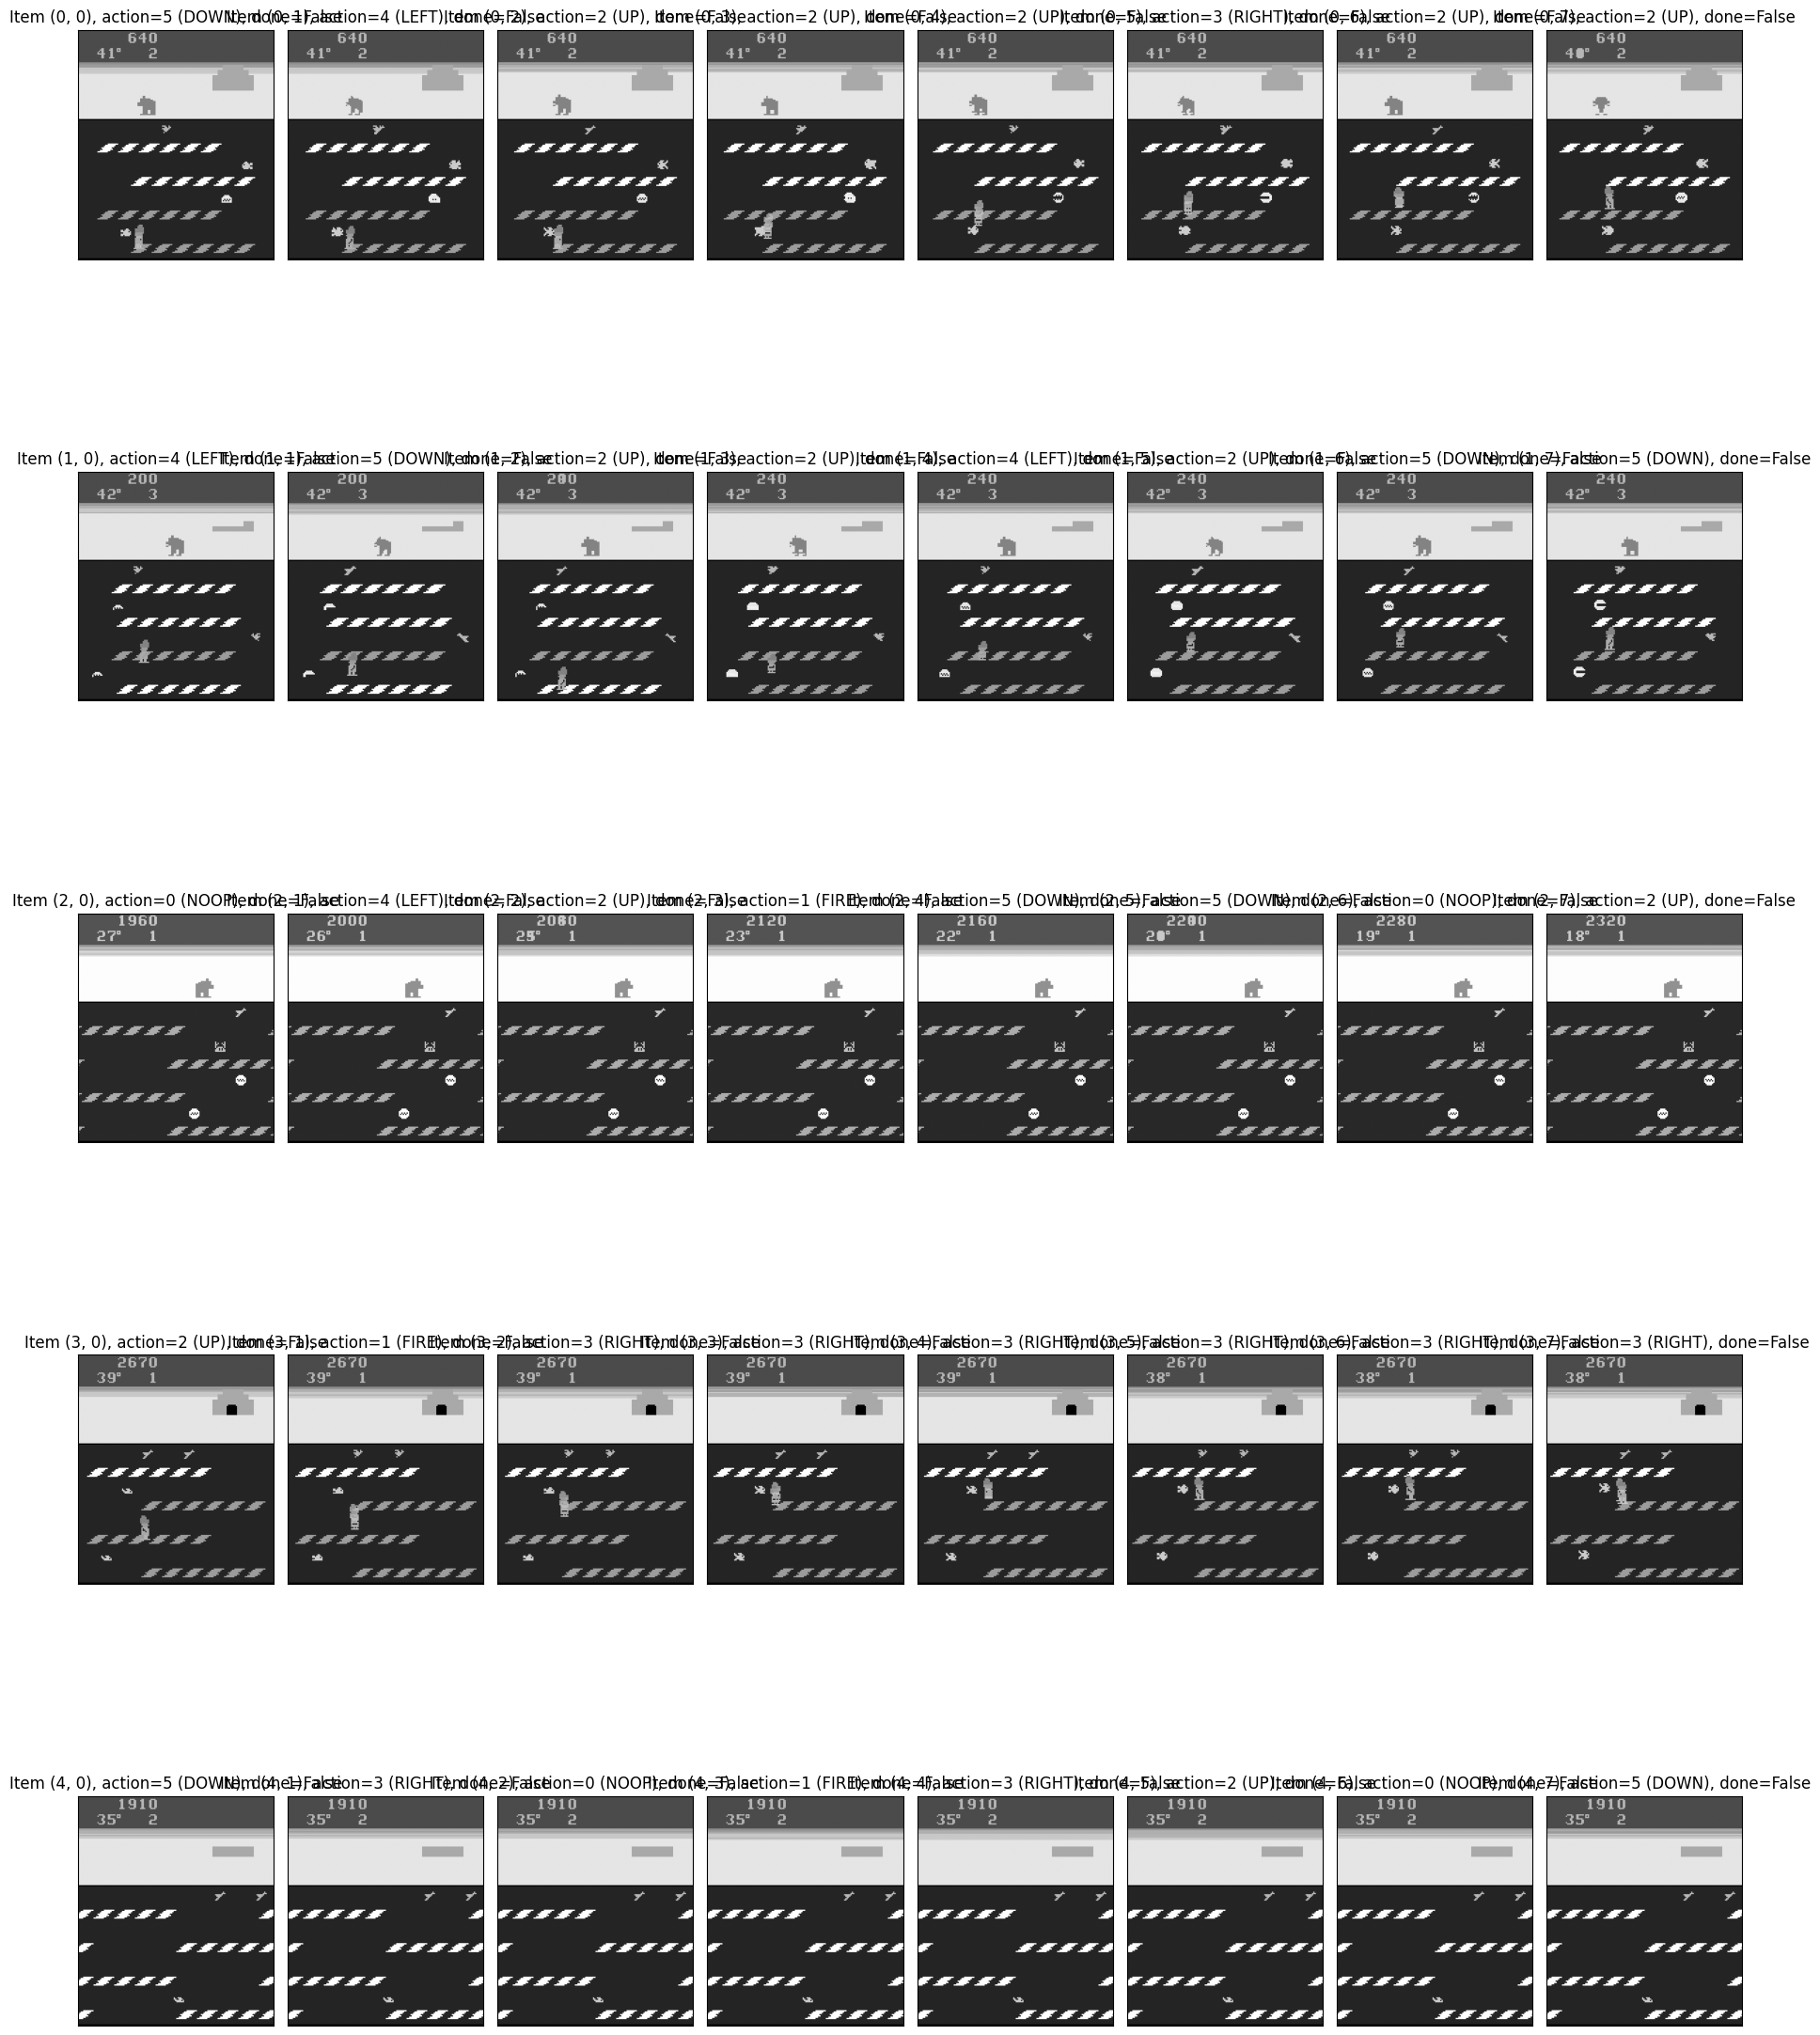

In [122]:
# @launchit.disable
l = len(RT.render_test_batch.obs)
s = RT.render_test_batch.obs.shape[1]
fig, axes = plt.subplots(l, s)
fig.set_figwidth(18)
fig.set_figheight(5 * len(axes))

for i, (pmasks, obs, actions, dones) in enumerate(zip(RT.render_test_batch.pmasks, RT.render_test_batch.obs, RT.render_test_batch.actions, RT.render_test_batch.dones)):
    for j, ax in enumerate(axes[i]):
        kwargs = dict(cmap='gray')
        action_name = ale_py.Action(actions[j].item()).name
        ax.set_title(f'Item {i,j}, action={actions[j]} ({action_name}), done={dones[j].bool()}')
        ax.imshow(obs[j].squeeze(0).cpu(), **kwargs)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()

# WorldModel

In [18]:
# @launchit.collect_export
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
from torch.nn.attention import SDPBackend, sdpa_kernel

## VisionHead

In [19]:
# @launchit.collect_export
class VisionHead(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = None
        input_shape: tuple = (1, 178, 152)
        grid: tuple = None # output features grid
        features_counts: tuple = None # how many output features per CNN layer
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        self.params.input_shape = tuple(params.input_shape)
        self.params.grid = tuple(params.grid)
        self.params.features_counts = tuple(params.features_counts)

        if self.params.input_shape == (1, 178, 152) or self.params.input_shape == (1, 178, 178):
            assert len(self.params.features_counts) == 4, len(self.params.features_counts)

            if self.params.grid == (6, 6):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (7, 7):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=2, padding=0), # -> (fc[3], 9, 8)
                    nn.ReLU(),
    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (9, 9):
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 87, 74)
                    nn.BatchNorm2d(self.params.features_counts[0]),
                    nn.ReLU(),
                    
                    # Layer 2: 87x74 -> 42x35
                    nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 42, 35)
                    nn.BatchNorm2d(self.params.features_counts[1]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=3, stride=2, padding=0), # -> (fc[2], 20, 17)
                    nn.BatchNorm2d(self.params.features_counts[2]),
                    nn.ReLU(),
                    
                    nn.Conv2d(self.params.features_counts[2], self.params.features_counts[3], kernel_size=3, stride=1, padding=0),  # -> (fc[3], 18, 15)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
            elif self.params.grid == (16, 16):
                self.cnn = nn.Sequential(
                    # Feature counts are hardcoded as in 18b_world_model
                    nn.Conv2d(1, 32, kernel_size=8, stride=4, padding=2), # -> (32, 44, 38)
                    nn.ReLU(),
                    
                    nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> (64, 22, 19)
                    nn.ReLU(),
                    
                    nn.Conv2d(64, self.params.d_model, kernel_size=3, stride=1, padding=1), # -> (256, 22, 19)
                    nn.ReLU(),
                    
                    nn.AdaptiveAvgPool2d(self.params.grid),
                )
        elif self.params.input_shape == (1, 45, 45) and self.params.grid == (5, 5):
            assert len(self.params.features_counts) == 3, len(self.params.features_counts)
            self.cnn = nn.Sequential(
                nn.Conv2d(1, self.params.features_counts[0], kernel_size=5, stride=2, padding=0), # -> (fc[0], 21, 21), detect raw edges/shapes
                nn.BatchNorm2d(self.params.features_counts[0]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[0], self.params.features_counts[1], kernel_size=5, stride=2, padding=0), # -> (fc[1], 9, 9), detect mid-level motion paths
                nn.BatchNorm2d(self.params.features_counts[1]),
                nn.ReLU(),
                
                nn.Conv2d(self.params.features_counts[1], self.params.features_counts[2], kernel_size=5, stride=1, padding=0), # -> (fc[2], 5, 5), shape extraction
                nn.ReLU(),
            )
        else:
            assert False, f'Unsupported {params.input_shape=}'

        self.out_tokens_count = math.prod(self.params.grid)
        self.out_features_count = self.params.features_counts[-1]
        self.post_ln = nn.LayerNorm(self.params.d_model)
        self.spatial_encoding = nn.Parameter(torch.randn(1, self.out_tokens_count, self.params.d_model))
        self.projector = nn.Linear(self.out_features_count, self.params.d_model)

    def forward(self, x):
        x_shape = x.shape
        x = x.view(-1, *x.shape[-3:]) # (uberbatch, color, height, width)
        features = self.cnn(x) # (uberbatch, out_features_count, sqrt(out_tokens_count), sqrt(out_tokens_count)) 
        features = features.permute(0, 2, 3, 1) # (uberbatch, sqrt(out_tokens_count), sqrt(out_tokens_count), out_features_count)
        features = features.view(len(features), -1, self.out_features_count) # (uberbatch, out_tokens_count, out_features_count)

        if self.params.grid == (16, 16):
            embs = features # (uberbatch, out_tokens_count, d_model)
        else:
            embs = self.projector(features) # (uberbatch, out_tokens_count, d_model)
            
        embs = self.post_ln(embs)
        embs += self.spatial_encoding
        return embs.view(*x.shape[:-3], self.out_tokens_count, self.params.d_model) # (..., out_tokens_count, d_model)

## RenderHead

In [20]:
# @launchit.collect_export
class RenderHead(nn.Module):
    @dataclass(slots=True)
    class Params:
        d_model: int = None
        ob_shape: tuple = (1, 178, 152)
        
    def __init__(self, params):
        super().__init__()
        self.params = params

        if self.params.ob_shape == (1, 178, 152):
            # kms@ more input features (e.g. 64 -> 128)
            # kms@ maybe normalization LayerNorm/GroupNorm?
            self.input_shape = (64, 11, 9)
            # kms@ think how to disallow adapter to take over logic of predicting latent stuff - 
            # latent stuff must be solely captured by g
            self.adapter = nn.Linear(self.params.d_model, math.prod(self.input_shape))
            self.renderer = nn.Sequential(
                nn.ConvTranspose2d(64, 48, kernel_size=4, stride=2, padding=1, output_padding=(0, 1)), # -> (48, 22, 19)
                nn.ReLU(),
                nn.ConvTranspose2d(48, 32, kernel_size=4, stride=2, padding=1), # -> (32, 44, 38)
                nn.ReLU(),
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1, output_padding=(1, 0)), # -> (16, 89, 76)
                nn.ReLU(),
                nn.ConvTranspose2d(16, 2, kernel_size=4, stride=2, padding=1), # -> 2, 178, 152) # pixel importance (gate) + pixel instensity (content)
                # no nn.Sigmoid here because of AMP and BCELoss. AMP forces to uses BCEWithLogitsLoss
            )
        else:
            assert False, f'Unsupported {self.params.ob_shape=}'

    def forward(self, g):
        # g must contain all data sufficient to render observation
        # g.shape = (batch, g_count, d_model)
        g_shape = g.shape
        y = self.adapter(g) # (batch, g_count, 64 * 11 * 9)
        y = y.view(-1, *self.input_shape) # defactorize last dim (uberbatch, 64, 11, 9)
        y = self.renderer(y) # (uberbatch, 2, *self.params.ob_shape)
        return y.view(*g_shape[:2], 2, *self.params.ob_shape) # (batch, g_count, 2, *self.params.ob_shape)

## WorldModel

In [21]:
# @launchit.collect_export
class WorldModel(nn.Module):
    @dataclass(slots=True)
    class Params:
        is_reconstruction: bool = False
        is_prediction: bool = False
        sequence_length: int = None
        ob_shape: tuple = (1, 178, 152)
        ob_vision_head: dict = None
        actions_count: int = None
        g_encoding: dict = None
        d_model: int = None
        layers_count: int = None
        heads_count: int = None
        render_heads_count: int = None
        attention_backend: str = None
        
    def __init__(self, params):
        super().__init__()
        self.params = params
        assert isinstance(self.params.ob_shape, (tuple, list)), self.params.ob_shape
        self.params.ob_shape = tuple(params.ob_shape)
        assert self.params.sequence_length >= 1, self.params.sequence_length

        assert self.params.ob_vision_head is not None
        ob_vision_head_params = VisionHead.Params(
            d_model=self.params.d_model, 
            input_shape=self.params.ob_shape,
            grid=self.params.ob_vision_head['grid'],
            features_counts=self.params.ob_vision_head['features_counts'],
        )
        self.ob_vision_head = VisionHead(ob_vision_head_params)

        self.tokens_per_ob = self.ob_vision_head.out_tokens_count
        assert self.tokens_per_ob > 0
        self.tokens_per_seq = self.tokens_per_ob * self.params.sequence_length # e.g., (36 + 4 * 25) * 4 = 544 or (36 + 2 * 25) * 4 = 344

        self.temporal_encoding = nn.Parameter(torch.randn(1, self.params.sequence_length, 1, self.params.d_model)) # seq number (0,1,2,3...) -> embedding

        assert self.params.actions_count > 0
        self.action_encoding = nn.Embedding(self.params.actions_count, self.params.d_model)

        # world state latent variables (g) - the main ingredient for restoration of current obs / prediction of next obs
        # Two ways:
        # 1) either different initial embeddings. This way it will naturally encode time in an initial embedding
        # 2) common initial embedding but with additional temporal encoding to differentiate in time
        self.g_count = 0
        self.g0_encoding = None

        if self.params.is_reconstruction:
            if self.params.g_encoding.get('is_common', False):
                self.g0_encoding = nn.Parameter(torch.randn(1, 1, self.params.d_model)) # common starting point for each g0 (reconstruction)
            else:
                self.g0_encoding = nn.Parameter(torch.randn(1, self.params.sequence_length, self.params.d_model)) # different starting points for each g0 (reconstruction)
                
            self.g_count += self.params.sequence_length

        self.g1_encoding = None

        if self.params.is_prediction:
            if self.params.g_encoding.get('is_common', False):
                self.g1_encoding = nn.Parameter(torch.randn(1, 1, self.params.d_model)) # common starting point for each g1 (prediction)
            else:
                self.g1_encoding = nn.Parameter(torch.randn(1, self.params.sequence_length, self.params.d_model)) # different starting points for each g1 (prediction)
                
            self.g_count += self.params.sequence_length
        
        self.internal_sequence_length = self.tokens_per_seq + self.g_count

        causal_mask = self.generate_block_shaped_causal_mask()
        self.register_buffer('causal_mask', causal_mask)
        
        transformer_layer = nn.TransformerEncoderLayer(
            d_model=self.params.d_model, 
            dim_feedforward=self.params.d_model * 4, # kms@ default is 2048, 256 * 4 = 2048
            nhead=self.params.heads_count, 
            batch_first=True,
            norm_first=True,  # preferred for RL tasks
            dropout=0.0,      # Dropout destroys RL performance; keep 0.0
        )

        # One could think about transformer as a RNN on steroids. Each layer is an unrolled RNN step with its own weights.
        # And also it obtains Hebbian-like memory with perfect storage without noise (input sequence)
        self.transformer = nn.TransformerEncoder(
            transformer_layer, 
            num_layers=self.params.layers_count,
            enable_nested_tensor=False, # True is incompatible with layers where norm_first=True
        )
        self._init_transformer_weights(self.transformer)
        
        self.post_transformer_ln = nn.LayerNorm(self.params.d_model) 

        if self.params.ob_shape == (1, 178, 152):
            render_head_params = RenderHead.Params(d_model=self.params.d_model, ob_shape=self.params.ob_shape)
            self.render_heads = nn.ModuleList([
                RenderHead(render_head_params) for _ in range(self.params.render_heads_count)
            ])
        else:
            assert False, f'Unsupported {self.params.ob_shape=}'

        self.attention_backend = getattr(SDPBackend, self.params.attention_backend)

    @property
    def grad_norm_groups(self):
        groups = dict(
            temporal_encoding=[self.temporal_encoding],
            action_encoding=list(self.action_encoding.parameters()),
            transformer=list(self.transformer.parameters()),
            render_heads=list(self.render_heads.parameters()),
        )

        if self.ob_vision_head is not None:
            groups['ob_vision_head'] = list(self.ob_vision_head.parameters())

        if self.g0_encoding is not None:
            groups['g0_encoding'] = [self.g0_encoding]

        if self.g1_encoding is not None:
            groups['g1_encoding'] = [self.g1_encoding]

        return groups

    ForwardResult = namedtuple('ForwardResult', 'recon, pred')
    RenderData = namedtuple('RenderData', 'pixel_logits, pixel_contents, pixel_gates, pixel_alpha_masks')

    def forward(self, obs, actions, padding_masks):
        # obs.shape = [batch, seq, color, height, width]
        # actions.shape = [batch, seq]
        # shape of padding_masks: [batch, seq]
        batch_size = len(obs)
        seq_len = obs.shape[1]

        # EMBED INPUT DATA
        x = self.embed_input_data(obs, actions) # (batch, seq, toks, d_model)
        assert x.shape[2] == self.tokens_per_ob
        x = x.view(batch_size, -1, self.params.d_model) # (batch, bag, d_model), where bag = seq*toks

        # ALIGN PADDING MASKS WITH X SHAPE
        # obs are left-padded, i.e. the very fresh obs is [:,-1] within each batch (env) is the last one
        # since each seq item (ob) is exploded into self.tokens_per_ob tokens we need to adjust padding_masks, e.g. 
        # t = torch.tensor([[1, 0, 1, 0], [1, 0, 0, 1]])
        # torch.repeat_interleave(t, 3, dim=1)
        # tensor([[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        #         [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1]])
        assert padding_masks.shape == (batch_size, seq_len)
        padding_masks = torch.repeat_interleave(padding_masks, self.tokens_per_ob, dim=1) # (batch, bag)
        assert padding_masks.shape == (batch_size, seq_len * self.tokens_per_ob), padding_masks.shape

        # ATTACH G TOKENS TO X
        for g_encoding in (self.g0_encoding, self.g1_encoding):
            if g_encoding is not None:
                if self.params.g_encoding.get('is_common', False):
                    g_embs = g_encoding.expand(batch_size, self.params.sequence_length, -1)
                else:
                    g_embs = g_encoding.expand(batch_size, -1, -1)
                    
                x = torch.cat([x, g_embs], dim=1) # (batch, bag, d_model)->(batch, bag+g_embs.shape[1], d_model)
    
        assert x.shape == (batch_size, self.internal_sequence_length, self.params.d_model), x.shape
        # g_embs are not pad masked so add zeros to padding_masks
        padding_masks = torch.cat([padding_masks, torch.zeros(batch_size, self.g_count, dtype=padding_masks.dtype, device=padding_masks.device)], dim=1)
        assert padding_masks.shape == (batch_size, seq_len * self.tokens_per_ob + self.g_count), padding_masks.shape

        # TRANSFORM
        with sdpa_kernel(self.attention_backend):
            y = self.transformer(
                x, 
                src_key_padding_mask=padding_masks,
                mask=self.causal_mask, 
                is_causal=False, # block-shaped mask is used which is not like a standard causal mask 
            )

        y = self.post_transformer_ln(y)

        # RENDER 
        g = y[:,-self.g_count:] # (batch, g_count, d_model) grab embs which correspond to calculated g latent vars which must capture all data to render reconstr/predict obs
        pixel_logits, pixel_contents, pixel_gates, pixel_alpha_masks = self.render_obs(g) # (batch, g_count, *ob_shape)

        # RETURN RESULT
        recon_data = None
        g0_count = 0

        if self.g0_encoding is not None:
            g0_count = self.g0_encoding.shape[1]
            recon_data = WorldModel.RenderData(
                pixel_logits=pixel_logits[:,:g0_count],
                pixel_contents=pixel_contents[:,:g0_count],
                pixel_gates=pixel_gates[:,:g0_count],
                pixel_alpha_masks=pixel_alpha_masks[:,:g0_count],
            )

        pred_data = None

        if self.g1_encoding is not None:
            pred_data = WorldModel.RenderData(
                pixel_logits=pixel_logits[:,g0_count:],
                pixel_contents=pixel_contents[:,g0_count:],
                pixel_gates=pixel_gates[:,g0_count:],
                pixel_alpha_masks=pixel_alpha_masks[:,g0_count:],
            )

        return WorldModel.ForwardResult(recon=recon_data, pred=pred_data)

    def generate_block_shaped_causal_mask(self):
        # https://gist.github.com/kocherovms/0038eac144ca468792454fb6f5e544e5
        # Main idea: 
        # 1) tokens within single observation could attend to each other and to tokens from prev obs but cannot attend to tokens from future obs
        # 2) g_0 token could attend to tokens from first ob only and itself
        # 3) g_1 token could attend to tokens from first and second obs only and itself
        # 4) g_i could attend to tokens from [0:i+1] obs only and itself
        # Alternative idea:
        # 1) tokenes within single ob could attend to each other and to tokenes from prev obs but cannot attend to tokenes from future obs
        # 2) g_0 token could attend to tokenes from first ob only and itself
        # 3) g_1 token could attend to tokenes from first and second obs only, itself and g_0
        # 4) g_i could attend to tokens from [0:i+1] obs only, itself and all previous g_j
        cm = nn.Transformer.generate_square_subsequent_mask(self.params.sequence_length)
        cm = torch.where(torch.isinf(cm), 1, 0)
        cm1 = torch.repeat_interleave(cm, self.tokens_per_ob, dim=1)
        cm2 = torch.repeat_interleave(cm1, self.tokens_per_ob, dim=0)
        cm3 = torch.ones(self.internal_sequence_length, self.internal_sequence_length)
        cm3[0:len(cm2),0:len(cm2)] = cm2
        cm3[len(cm2):,len(cm2):] = torch.where(torch.eye(self.g_count) == 1, 0, 1)
        
        # g0 and g1 groups independently attend to tokens
        g_groups_count = int(self.g0_encoding is not None) + int(self.g1_encoding is not None)

        for i in range(g_groups_count):
            lo_i = len(cm2) + len(cm1) * i
            hi_i = lo_i + len(cm1)
            cm3[lo_i:hi_i,:len(cm2)] = cm1
        
        return torch.where(cm3 == 1, -torch.inf, cm3)

    def embed_input_data(self, obs, actions):
        # obs.shape = [batch, seq, color, height, width]
        # actions.shape = [batch, seq]
        batch_size = len(obs)
        seq_len = obs.shape[1]
        assert len(actions) == batch_size, (len(actions), batch_size)
        assert actions.shape[1] == seq_len, (actions.shape[1], seq_len)
        embs = []
        obs = obs.unsqueeze(2) # introduce fake pov dimension to unify with povs handling. I.e. treat observation as a single POV without coordinates

        # Groundwork for POV is left here
        for coords, povs, vision_head in zip((None,), (obs,), (self.ob_vision_head,)):
            if vision_head is None:
                continue
            
            if povs.dtype == torch.uint8:
                povs = povs / 255.0
            else:
                assert torch.all((0 <= povs) & (povs <= 1.0))

            assert len(povs.shape) == 6, len(povs.shape)
            assert povs.shape[0] == batch_size, (povs.shape[0], batch_size)
            assert povs.shape[1] == seq_len, (povs.shape[1], seq_len)
            assert povs.shape[-3:] == vision_head.params.input_shape, (povs.shape[-3:], vision_head.params.input_shape)
            assert coords is None or coords.shape[2] == povs.shape[2]
            povs_count = povs.shape[2]
            assert povs_count > 0

            povs = povs.reshape(-1, *povs.shape[-3:]) # (uberbatch, color, height, width) # kms@ reshape vs view after input_obs
            pov_embs = vision_head(povs) # (uberbatch, vision_head.out_tokens_count, d_model)
            pov_embs_per_pov = pov_embs.shape[1]
            pov_embs = pov_embs.view(batch_size, seq_len, povs_count, pov_embs_per_pov, self.params.d_model) # (batch, seq, povs, vision_head.out_tokens_count, d_model)

            # Label each pov with its coordinate location
            if coords is not None:
                pov_coords_embs = self.pov_coords_encoding(coords) # (batch, seq, povs, d_model)
                pov_coords_embs = pov_coords_embs.view(batch_size, seq_len, povs_count, 1, self.params.d_model) # (batch, seq, povs, 1, d_model)
                pov_embs += pov_coords_embs

            pov_embs = pov_embs.view(batch_size, seq_len, -1, self.params.d_model) # (batch, seq, flattened povs, d_model)
            embs.append(pov_embs)

        assert len(embs) > 0
        
        # collate all embs with respect to batch and seq from various POVs. E.g. (2, 5, 36, 256), (2, 5, 2 * 25, 256) -> (2, 5, 36 + 2 * 25, 256)
        # in other words in dim=2 we would get all embs related to this seq item
        embs = torch.cat(embs, dim=2) # (batch, seq, all povs, d_model)

        # Label each seq item with corresponding time stamp (last item is a current one)
        assert self.temporal_encoding.shape == (1, seq_len, 1, self.params.d_model)
        embs += self.temporal_encoding
        
        # Label each seq item with corresponding action (which action is tied to this seq item)
        action_embs = self.action_encoding(actions) # (batch, seq, d_model)
        action_embs = action_embs.view(batch_size, seq_len, 1, self.params.d_model)
        embs += action_embs

        return embs

    def render_obs(self, g):
        # g must contain all data sufficient to render observation
        # g.shape = (batch, g_count, d_model)
        batch_size = len(g)
        contents = []
        gates = []
        
        # 1. Run the latent code through every generated expert pipeline
        for head in self.render_heads:
            out = head(g) # (batch, g_count, 2, self.params.ob_shape)
            contents.append(out[:,:,0:1]) # Proposed pixel intensities, (batch, g_count, 1, *self.params.ob_shape)
            gates.append(out[:,:,1:2])    # Proposed selection urgency, (batch, g_count, 1, *self.params.ob_shape)

        # Stack layers along a new dimension (dim=2)
        contents = torch.cat(contents, dim=2) # (batch, g_count, render_heads_count, *self.params.ob_shape)
        gates = torch.cat(gates, dim=2) # (batch, g_count, render_heads_count, *self.params.ob_shape)
        
        # 2. Compute Softmax-Gated Alpha Masks across the Layer Dimension
        # This mathematically forces the masks for every single pixel to sum to 1.0.
        # It creates a clean, fully differentiable competitive gate.
        alpha_masks = F.softmax(gates, dim=2)

        # 3. Blending Step: Element-wise multiply content by alpha, then sum across layers
        # This is a fully differentiable weighted average per pixel
        # Note: return raw logits since AMP requires BCEWithLogitsLoss which requires raw logits
        logits = torch.sum(contents * alpha_masks, dim=2) # (batch, g_count, 1, *self.params.ob_shape)
        return logits, contents, gates, alpha_masks

    def preprocess_obs(self, obs):
        assert isinstance(obs, torch.Tensor)
        assert obs.dtype == torch.uint8
        obs_ndim = obs.ndim
        assert obs_ndim >= 3 # height, width, color

        if obs_ndim == 3:
            obs = obs.unsqueeze(0) # ensure there is a batch dim
        
        obs_shape = obs.shape
        obs = obs.view(-1, *obs_shape[-3:])
        obs = obs.permute(0, 3, 1, 2) # move color channel to the front (switch interleaved->planar format)
        
        if self.params.ob_shape == (1, 178, 152):
            # kms@ actually can get rid of top and bottom lines (they are black) -> (176, 152)
            obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
            obs = obs[:,:,8:186,8:160] # extract only meaningful data for Frostbite
            obs = obs.view(*obs_shape[:-3], 1, 178, 152)
        elif self.params.ob_shape == (3, 84, 84):
            obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
            obs = obs.view(*obs_shape[:-3], 3, 84, 84)
        elif self.params.ob_shape == (1, 84, 84):
            obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
            obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
            obs = obs.view(*obs_shape[:-3], 1, 84, 84)
        else:
            assert False, f'Unsupported {self.params.ob_shape=}'
        
        if obs_ndim == 3:
            obs = obs.squeeze(0)
        
        return obs

    @staticmethod
    def _init_weights(l, gain=np.sqrt(2), bias_const=0.0):
        '''
        CleanRL style orthogonal initialization helper
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        nn.init.orthogonal_(l.weight, gain=gain)
        
        if l.bias is not None:
            nn.init.constant_(l.bias, bias_const)
            
        return l

    @staticmethod
    def _init_transformer_weights(t):
        '''
        Applies orthogonal initialization to the inner transformer blocks.
        https://share.google/aimode/BDty0f9ZJZ6OXBFFQ
        '''
        
        for name, param in t.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                # Appling gain=1.0 keeps variance stable across depth
                nn.init.orthogonal_(param, gain=1.0)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

## Test

### Basics

In [22]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
# t.device = 'cpu'
t.pov_size = 45

t.wmp = WorldModel.Params(
    is_reconstruction=True,
    is_prediction=True,
    sequence_length=4,
    ob_shape=(1, 178, 152),
    ob_vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
    actions_count=6,
    d_model=256,
    layers_count=3,
    heads_count=4,
    render_heads_count=4,
    attention_backend=lu.when(CONFIG.is_cuda, 'EFFICIENT_ATTENTION', 'MATH')
)
t.model = WorldModel(t.wmp).to(t.device)
print(t.model)
t.params_count = sum(p.numel() for p in t.model.parameters())
print(f'{t.params_count=:_}')

t.envs_count = 2
t.steps_count = 10

t.obs = torch.zeros(t.envs_count, t.wmp.sequence_length, *t.wmp.ob_shape, dtype=torch.uint8).to(t.device)
t.pmasks = torch.zeros(t.envs_count, t.wmp.sequence_length).to(t.device)
t.actions = torch.zeros(t.envs_count, t.wmp.sequence_length, dtype=torch.int).to(t.device)

print(f'{t.obs.shape=}')
print(f'{t.pmasks.shape=}')
print(f'{t.actions.shape=}')

t.fr = t.model(t.obs, t.actions, t.pmasks)

print(f'{t.fr.recon.pixel_logits.shape=}')
print(f'{t.fr.recon.pixel_contents.shape=}')
print(f'{t.fr.recon.pixel_gates.shape=}')
print(f'{t.fr.recon.pixel_alpha_masks.shape=}')

print(f'{t.fr.pred.pixel_logits.shape=}')
print(f'{t.fr.pred.pixel_contents.shape=}')
print(f'{t.fr.pred.pixel_gates.shape=}')
print(f'{t.fr.pred.pixel_alpha_masks.shape=}')

WorldModel(
  (ob_vision_head): VisionHead(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(6, 6))
    )
    (projector): Linear(in_features=128, out_features=256, bias=True)
    (post_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (action_encoding): Embedding(6, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList

### is_reconstruction, is_prediction

In [23]:
# @launchit.disable
t = lu.ScopedVars()
t.device = CONFIG.cuda_device
t.pov_size = 45
t.variants = [
    dict(is_reconstruction=True, is_prediction=True),
    dict(is_reconstruction=True, is_prediction=False),
    dict(is_reconstruction=False, is_prediction=True),
    dict(is_reconstruction=False, is_prediction=False),
]

for t.var in t.variants:
    t.wmp = WorldModel.Params(
        is_reconstruction=t.var['is_reconstruction'],
        is_prediction=t.var['is_prediction'],
        sequence_length=1,
        ob_shape=(1, 178, 152),
        ob_vision_head=dict(grid=(6,6), features_counts=(16, 32, 64, 128)),
        actions_count=6,
        d_model=256,
        layers_count=3,
        heads_count=4,
        render_heads_count=4,
        attention_backend=lu.when(CONFIG.is_cuda, 'EFFICIENT_ATTENTION', 'MATH')
    )
    t.model = WorldModel(t.wmp).to(t.device)
    print(t.model)
    t.params_count = sum(p.numel() for p in t.model.parameters())
    print(f'{t.params_count=:_}')
    
    t.envs_count = 2
    t.steps_count = 10
    
    t.obs = torch.zeros(t.envs_count, t.wmp.sequence_length, *t.wmp.ob_shape, dtype=torch.uint8).to(t.device)
    t.pmasks = torch.zeros(t.envs_count, t.wmp.sequence_length).to(t.device)
    t.actions = torch.zeros(t.envs_count, t.wmp.sequence_length, dtype=torch.int).to(t.device)
    t.fr = t.model(t.obs, t.actions, t.pmasks)
    print('')

WorldModel(
  (ob_vision_head): VisionHead(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(6, 6))
    )
    (projector): Linear(in_features=128, out_features=256, bias=True)
    (post_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (action_encoding): Embedding(6, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList

## Configure

In [24]:
# @launchit.disable
# @launchit.collect
HP.model.parent = None
HP.model.is_reconstruction = True 
HP.model.is_prediction = True
HP.model.sequence_length = 4
HP.model.ob_shape = (1, 178, 152)
HP.model.ob_vision_head = dict(grid=(6,6), features_counts=(16, 32, 64, 128))
HP.model.actions_count = 6
HP.model.g_encoding = dict(is_shared=True)
HP.model.d_model = 256
HP.model.layers_count = 3
HP.model.heads_count = 4
HP.model.render_heads_count = 4
HP.model.attention_backend = 'MATH' # MATH, EFFICIENT_ATTENTION, FLASH_ATTENTION
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 92,
            'is_torch_deterministic': True,
            'is_torch_compile': False,
            'use_amp': True},
 'dataset': {'train': ['train_dataset:100',
                       'train_dataset:101',
                       'train_dataset:102',
                       'train_dataset:103',
                       'train_dataset:104',
                       'train_dataset:105',
                       'train_dataset:106',
                       'train_dataset:107',
                       'train_dataset:108',
                       'train_dataset:109'],
             'test': 'test_dataset:2'},
 'model': {'parent': None,
           'is_reconstruction': True,
           'is_prediction': True,
           'sequence_length': 4,
           'ob_shape': (1, 178, 152),
           'ob_vision_head': {'grid': (6, 6),
                              'features_counts': (16, 32

## Initrd

In [25]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig' and HP.model.parent:
    coords = hp_parse_artifact_source(HP.model.parent)
    CONFIG.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='json', asset_classifier='world_model_params', maven_group_id=coords.group_id)
    CONFIG.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='pt', asset_classifier='world_model', maven_group_id=coords.group_id)
# @launchit.stop

## Create

In [26]:
if HP.model.parent is not None:
    coords = hp_parse_artifact_source(HP.model.parent)
    
    model_params_data = RT.artifact_registry.get_asset_content(
        coords.model_name, coords.model_version, asset_ext='json', asset_classifier='world_model_params', maven_group_id=coords.group_id
    )
    model_params = WorldModel.Params(**json.loads(model_params_data.decode()))

    RT.world_model = WorldModel(model_params).to(CONFIG.cuda_device)
    LOG(f'WorldModel created')
    
    if HP.system.is_torch_compile:
        RT.world_model = torch.compile(RT.world_model, fullgraph=True)
        LOG(f'WorldModel compiled') 
    
    model_weights_data = RT.artifact_registry.get_asset_content(
        coords.model_name, coords.model_version, asset_ext='pt', asset_classifier='world_model', maven_group_id=coords.group_id
    )
    
    with io.BytesIO(model_weights_data) as b:
        kwargs = {}
        
        if not CONFIG.is_cuda:
            kwargs['map_location'] = torch.device('cpu')
            
        RT.world_model.load_state_dict(torch.load(b, **kwargs))

    LOG(f'WorldModel state loaded from "{HP.model.parent}"')
else:
    wmp = WorldModel.Params(
        is_reconstruction=HP.model.is_reconstruction,
        is_prediction=HP.model.is_prediction,
        sequence_length=HP.model.sequence_length,
        ob_shape=HP.model.ob_shape,
        ob_vision_head=HP.model.ob_vision_head,
        actions_count=HP.model.actions_count,
        g_encoding=HP.model.g_encoding,
        d_model=HP.model.d_model,
        layers_count=HP.model.layers_count,
        heads_count=HP.model.heads_count,
        render_heads_count=HP.model.render_heads_count,
        attention_backend=HP.model.attention_backend,
    )
    
    RT.world_model = WorldModel(wmp).to(CONFIG.cuda_device)
    LOG(f'WorldModel created')
    
    if HP.system.is_torch_compile:
        RT.world_model = torch.compile(RT.world_model, fullgraph=True)
        LOG(f'WorldModel compiled') 

WorldModel created


# TRAIN

## EdgeDetector

In [27]:
# @launchit.collect_explore
# https://share.google/aimode/910bVkcGs9nvCh9Q8
class EdgeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        # Sobel filters to extract horizontal and vertical edges
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # Register as buffers so they move to the correct GPU automatically
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    ForwardResult = namedtuple('ForwardResult', 'grad_x, grad_y, magnitude')    
    
    def forward(self, x):
        # x shape: (Batch, 1, H, W)
        padded = F.pad(x, (1, 1, 1, 1), mode='replicate') # Pad edges to keep sizes matching
        grad_x = F.conv2d(padded, self.sobel_x)
        grad_y = F.conv2d(padded, self.sobel_y)
        magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
        return EdgeDetector.ForwardResult(grad_x=grad_x, grad_y=grad_y, magnitude=magnitude)

## render_reconstructions

In [28]:
def render_reconstructions(model, batch, edge_detector):
    assert batch.pmasks.sum() == 0, 'Expected no padding sequences in render batch yet'
    assert batch.obs.shape[1] == model.params.sequence_length + 1
    obs = batch.obs[:,:-1] / 255.0

    with torch.no_grad():
        mfr = model(
            obs=obs, 
            actions=batch.actions[:,:-1], 
            padding_masks=batch.pmasks[:,:-1],
        )
        reconstr_obs = torch.sigmoid(mfr.recon.pixel_logits) # logits -> pixel values
        assert reconstr_obs.shape == obs.shape
        assert len(reconstr_obs) < 10

        obs_cpu = obs.cpu()
        actions_cpu = batch.actions.cpu()

        for i in range(len(reconstr_obs)):
            fig, axes = plt.subplots(2, reconstr_obs.shape[1], squeeze=False)
            fig.set_figwidth(16)
            fig.set_figheight(4 * len(axes))
            fig.set_constrained_layout(True)

            for j in range(reconstr_obs.shape[1]):
                cmap_name = 'gray'
                
                action = actions_cpu[i,j].item()
                action_name = ale_py.Action(action).name
                ob = obs_cpu[i,j]

                axes[0,j].set_title(f'{i,j}, action={action} ({action_name}), done={batch.dones[i,j].int()}', fontdict=dict(fontsize=10))
                axes[0,j].imshow(ob.squeeze(0), cmap=cmap_name)
                axes[0,j].set_xticks([])
                axes[0,j].set_yticks([])

                if j == 0:
                    axes[0,j].set_ylabel('ob', rotation=90, size=12, labelpad=15, verticalalignment='center')

                reconstr_ob = reconstr_obs[i,j]
                ob = obs[i,j]
                bce_loss = F.binary_cross_entropy(reconstr_ob, ob)
                reconstr_edges = edge_detector(reconstr_ob.unsqueeze(0))
                true_edges = edge_detector(ob.unsqueeze(0))
                edge_loss = F.mse_loss(reconstr_edges.magnitude, true_edges.magnitude)
                ssim = piq.ssim(reconstr_ob.unsqueeze(0), ob.unsqueeze(0)).item()
                
                axes[1,j].set_title(f'{i,j}, ' + 
                                    f'ssim={ssim:.3f}, ' + 
                                    f'bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}', fontdict=dict(fontsize=10))
                axes[1,j].imshow(reconstr_ob.cpu().squeeze(0), cmap=cmap_name)
                axes[1,j].set_xticks([])
                axes[1,j].set_yticks([])

                if j == 0:
                    axes[1,j].set_ylabel('reconstr_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')

            yield fig, ssim

## render_predictions

In [29]:
def render_predictions(model, batch, edge_detector):
    assert batch.pmasks.sum() == 0, 'Expected no padding sequences in render batch yet'
    assert batch.obs.shape[1] == model.params.sequence_length + 1
    
    with torch.no_grad():
        mfr = model(
            obs=batch.obs[:,:-1] / 255.0,
            actions=batch.actions[:,:-1],
            padding_masks=batch.pmasks[:,:-1],
        )
        true_next_obs = batch.obs[:,1:] / 255.0
        pred_next_obs = torch.sigmoid(mfr.pred.pixel_logits) # logits -> pixel values
        assert pred_next_obs.shape == true_next_obs.shape
        assert len(pred_next_obs) < 10

        obs = batch.obs.cpu()
        actions = batch.actions.cpu()

        for i in range(len(pred_next_obs)):
            fig, axes = plt.subplots(3, pred_next_obs.shape[1])
            fig.set_figwidth(16)
            fig.set_figheight(4 * len(axes))
            fig.set_constrained_layout(True)

            for j in range(pred_next_obs.shape[1]):
                cmap_name = 'gray'
                
                action = actions[i,j]
                action_name = ale_py.Action(action.item()).name
                ob = obs[i,j]
                
                axes[0,j].set_title(f'{i,j}, action={action} ({action_name}), done={batch.dones[i,j].int()}', fontdict=dict(fontsize=10))
                axes[0,j].imshow(ob.squeeze(0), cmap=cmap_name)
                axes[0,j].set_xticks([])
                axes[0,j].set_yticks([])

                if j == 0:
                    axes[0,j].set_ylabel('ob', rotation=90, size=12, labelpad=15, verticalalignment='center')
                
                true_next_ob = true_next_obs[i,j]
                bce_loss = F.binary_cross_entropy(true_next_ob, true_next_ob)
                true_edges = edge_detector(true_next_ob.unsqueeze(0))
                edge_loss = F.mse_loss(true_edges.magnitude, true_edges.magnitude)
                
                axes[1,j].set_title(f'{i,j}, bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}, done={batch.dones[i,j+1].int()}', fontdict=dict(fontsize=10))
                axes[1,j].imshow(true_next_ob.cpu().squeeze(0), cmap=cmap_name)
                axes[1,j].set_xticks([])
                axes[1,j].set_yticks([])

                if j == 0:
                    axes[1,j].set_ylabel('true_next_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')

                pred_next_ob = pred_next_obs[i,j]
                bce_loss = F.binary_cross_entropy(pred_next_ob, true_next_ob)
                pred_edges = edge_detector(pred_next_ob.unsqueeze(0))
                true_edges = edge_detector(true_next_ob.unsqueeze(0))
                edge_loss = F.mse_loss(pred_edges.magnitude, true_edges.magnitude)
                ssim = piq.ssim(pred_next_ob.unsqueeze(0), true_next_ob.unsqueeze(0)).item()
                
                axes[2,j].set_title(f'{i,j}, ' + 
                                    f'ssim={ssim:.3f}, ' + 
                                    f'bce={bce_loss.item():.3f}, edge={edge_loss.item():.3f}', fontdict=dict(fontsize=10))
                axes[2,j].imshow(pred_next_ob.cpu().squeeze(0), cmap=cmap_name)
                axes[2,j].set_xticks([])
                axes[2,j].set_yticks([])

                if j == 0:
                    axes[2,j].set_ylabel('pred_next_ob', rotation=90, size=12, labelpad=15, verticalalignment='center')

            yield fig, ssim

## Configure

In [30]:
# @launchit.disable
# @launchit.collect
HP.train.epochs_count = 4
HP.train.batch_size = 128
HP.train.optimizer = 'AdamW'
HP.train.max_grad_norm = 1.0
HP.train.learn_rate = 'const(0.0005)'
HP.train.bce_loss_coef = 'const(1.0)'
HP.train.edge_loss_coef = 'const(1.0)'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 92,
            'is_torch_deterministic': True,
            'is_torch_compile': False,
            'use_amp': True},
 'dataset': {'train': ['train_dataset:100',
                       'train_dataset:101',
                       'train_dataset:102',
                       'train_dataset:103',
                       'train_dataset:104',
                       'train_dataset:105',
                       'train_dataset:106',
                       'train_dataset:107',
                       'train_dataset:108',
                       'train_dataset:109'],
             'test': 'test_dataset:2'},
 'model': {'parent': None,
           'is_reconstruction': True,
           'is_prediction': True,
           'sequence_length': 4,
           'ob_shape': (1, 178, 152),
           'ob_vision_head': {'grid': (6, 6),
                              'features_counts': (16, 32

## Create

In [31]:
ump = hp_parse_universal_module(HP.train.optimizer)
assert not ump.args
optimizer = getattr(torch.optim, ump.module_name)(RT.world_model.parameters(), **ump.kwargs)

ump = hp_parse_universal_module(HP.train.learn_rate)
lr_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.bce_loss_coef)
bce_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

ump = hp_parse_universal_module(HP.train.edge_loss_coef)
edge_loss_coef_anneal = get_anneal(ump.module_name, *ump.args, **ump.kwargs)

In [32]:
edge_detector = EdgeDetector()
edge_detector = edge_detector.to(CONFIG.cuda_device)

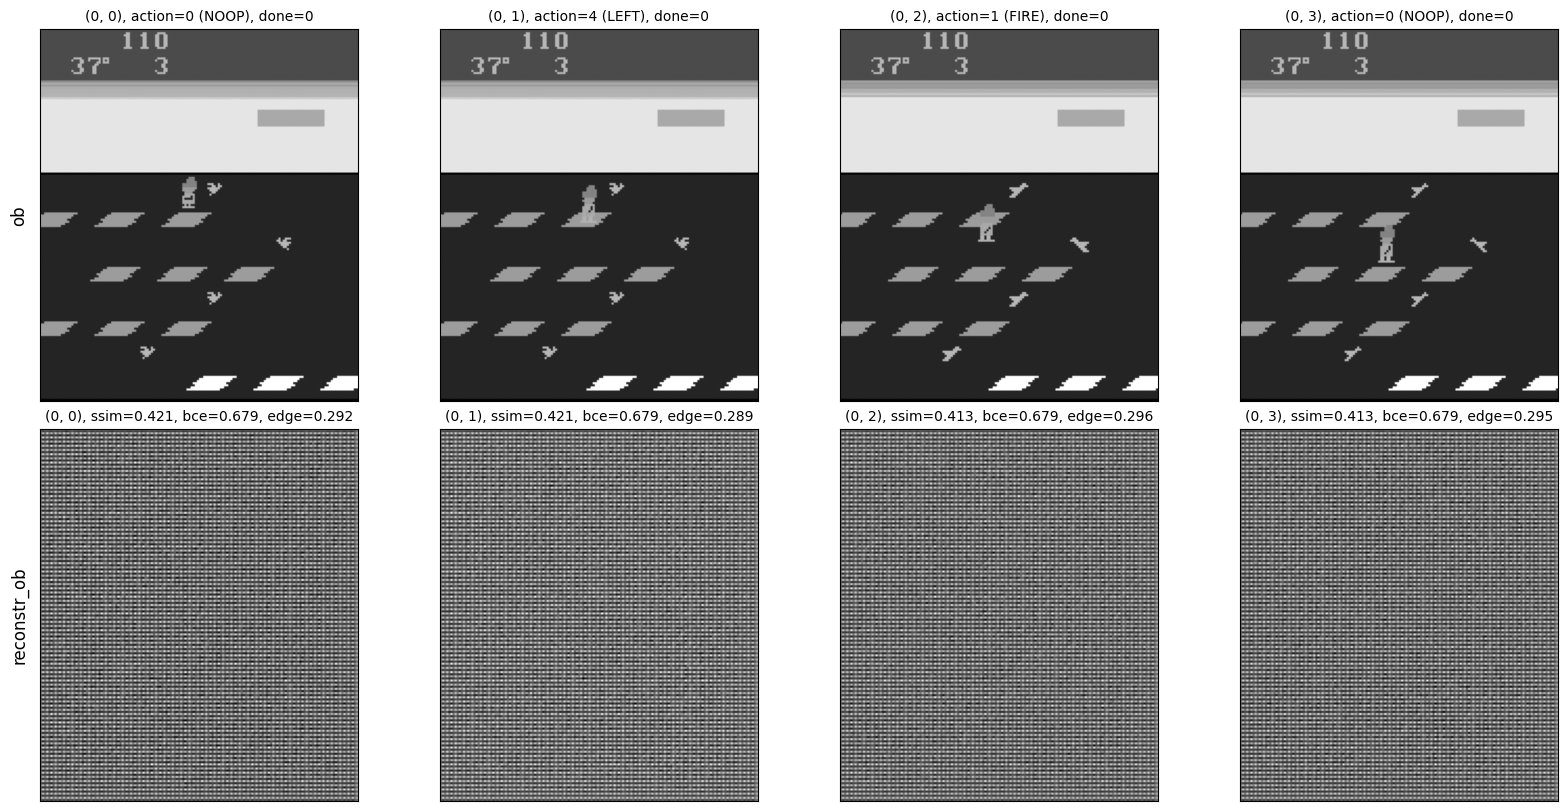

In [33]:
# @launchit.disable
for fig, _ in render_reconstructions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector):
    break

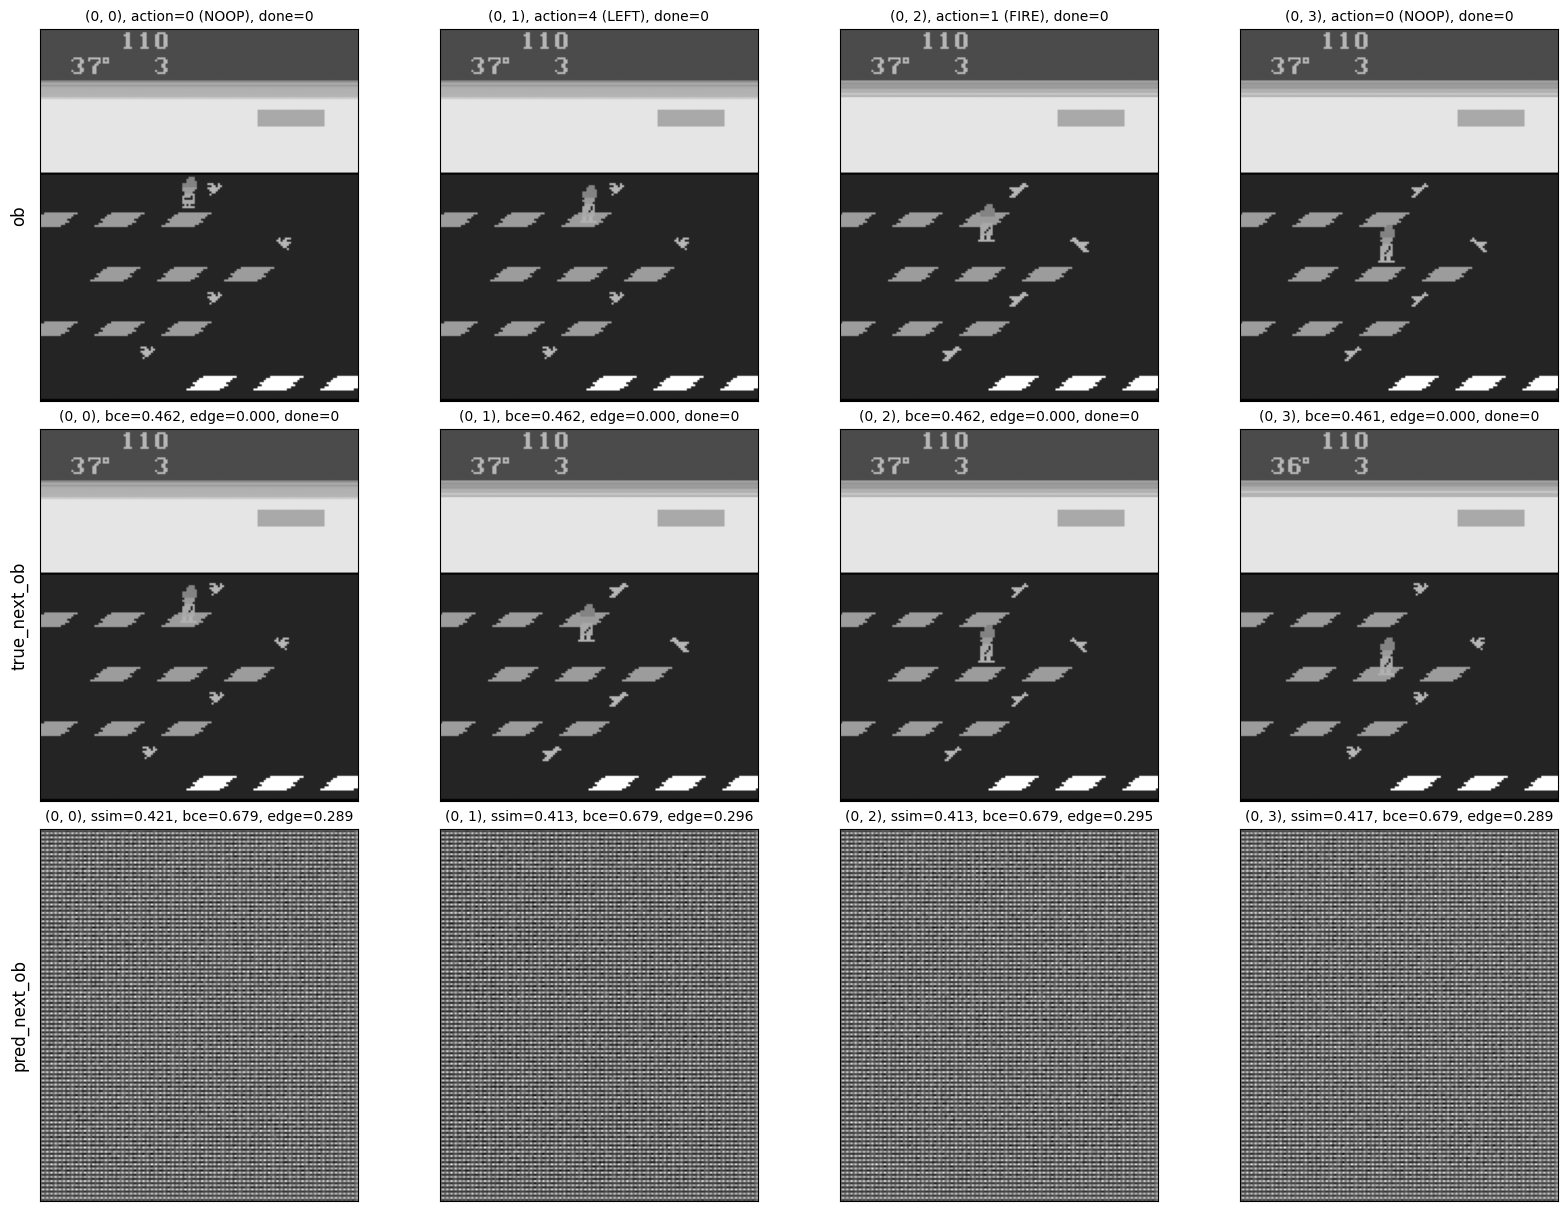

In [34]:
# @launchit.disable
for fig, _ in render_predictions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector):
    break

## Train

In [46]:
metrics_suite = defaultdict(list)
timings = {}
processed_batch_items = 0
test_dataset = load_dataset(RT.test_dataset_fname).clone().to(CONFIG.cuda_device)
test_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=False)

for epoch in tqdm(range(HP.train.epochs_count), desc='Epoch', disable=not CONFIG.is_interactive):
    old_processed_batch_items = processed_batch_items
    timings.clear()
    t0 = time.time()

    # ANNEAL
    progress = epoch / HP.train.epochs_count
    lr = lr_anneal(progress)
    for param_group in optimizer.param_groups: param_group['lr'] = lr
    bce_loss_coef = bce_loss_coef_anneal(progress)
    edge_loss_coef = edge_loss_coef_anneal(progress)

    t1 = time.time()
    train_dataset_id = RNG.choice(list(RT.train_datasets.keys())).item()
    LOG(f'{train_dataset_id=}', when=not CONFIG.is_interactive)
    train_dataset = load_dataset(RT.train_datasets[train_dataset_id])
    train_dataset = train_dataset.clone().to(CONFIG.cuda_device)
    train_dataset.init_iteration(batch_size=HP.train.batch_size, is_shuffled=True)

    # OPTIMIZATION
    for batch in tqdm(train_dataset, desc='Train batch', total=train_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
        # Important batch items invariants and conditions are highlighted in "rollout: pmasks, obs, actions, dones"

        # Need at least one obs for prediction, so filter out batch items which don't have enough items
        batch_mask = batch.pmasks.sum(axis=1) < RT.world_model.params.sequence_length
        batch = batch._replace(
            pmasks=batch.pmasks[batch_mask],
            obs=batch.obs[batch_mask],
            actions=batch.actions[batch_mask],
            dones=batch.dones[batch_mask],
        )
        assert len(batch.obs) > 0

        with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.system.use_amp):
            assert batch.obs.shape[1] - 1 == RT.world_model.params.sequence_length
            batch_size = len(batch.obs)
            obs = batch.obs / 255.0
            input_obs = obs[:,:-1] # all but the last
            pmasks = batch.pmasks[:,:-1]

            wmfr = RT.world_model(
                obs=input_obs, 
                actions=batch.actions[:,:-1], 
                padding_masks=pmasks,
            )
            # Get only unpadded obs, unravel first 2 dims to get flat list of images
            flat_masks = ~(pmasks.ravel().bool()) # 2-dim padding masks -> flat presence mask

            bce_loss, edge_loss = 0, 0
            recon_bce_loss, recon_edge_loss = 0, 0
            pred_bce_loss, pred_edge_loss = 0, 0
            losses_count = 0
            
            #### RECONSTRUCTION
            if wmfr.recon is not None:
                recon_obs = wmfr.recon.pixel_logits
                assert recon_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                recon_obs = recon_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                recon_obs = recon_obs[flat_masks] # (uberbatch, *ob_shape)
            
                true_obs = input_obs
                assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ reshape vs view after input_obs
                true_obs = true_obs[flat_masks] # (uberbatch, *ob_shape)
                
                recon_bce_loss = F.binary_cross_entropy_with_logits(recon_obs, true_obs) # recon_obs contains raw logits, so use BCE with logits!
                recon_edges = edge_detector(torch.sigmoid(recon_obs))
                true_edges = edge_detector(true_obs)
                recon_edge_loss = F.mse_loss(recon_edges.magnitude, true_edges.magnitude)
                
                bce_loss += recon_bce_loss
                edge_loss += recon_edge_loss
                losses_count += 1
            
            #### PREDICTION
            if wmfr.pred is not None:
                pred_obs = wmfr.pred.pixel_logits
                assert pred_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                pred_obs = pred_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                pred_obs = pred_obs[flat_masks] # (uberbatch, *ob_shape)
            
                true_obs = obs[:,1:] # next obs in sequence
                assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ reshape vs view after input_obs
                true_obs = true_obs[flat_masks] # (uberbatch, *ob_shape)

                pred_bce_loss = F.binary_cross_entropy_with_logits(pred_obs, true_obs) # pred_obs contains raw logits, so use BCE with logits!
                pred_edges = edge_detector(torch.sigmoid(pred_obs))
                true_edges = edge_detector(true_obs)
                pred_edge_loss = F.mse_loss(pred_edges.magnitude, true_edges.magnitude)
                
                bce_loss += pred_bce_loss
                edge_loss += pred_edge_loss
                losses_count += 1
            
            # 1. Pixel-level Loss (BCE scales cleanly for grayscale classification)/
            bce_loss = bce_loss / losses_count
            # 2. Edge-level Loss (Forces sharp silhouettes for small moving characters)
            edge_loss = edge_loss / losses_count
            
            # Total composite loss
            loss = (bce_loss_coef * bce_loss) + (edge_loss_coef * edge_loss)

        optimizer.zero_grad()
        loss.backward()
        group_grad_norms = calc_group_grad_norms(RT.world_model)
        grad_norm = lu.when(
            HP.train.max_grad_norm is not None,
            lambda: torch.nn.utils.clip_grad_norm_(RT.world_model.parameters(), max_norm=HP.train.max_grad_norm),
            0
        )
        optimizer.step()

        processed_batch_items += batch_size

    LOG(f'Optimization done', when=not CONFIG.is_interactive)
    timings['optimization'] = time.time() - t1

    # FOLLOW-UP optimization (first epoch, last epoch and every 10% of progress)
    if (epoch == 0) or (epoch == HP.train.epochs_count - 1) or (epoch % max(1, (HP.train.epochs_count // 10)) == 0): 
        t1 = time.time()
        recon_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
        recon_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
        recon_last_ob_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
        recon_last_ob_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
        pred_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
        pred_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)
        pred_last_ob_ssims_sum = torch.tensor(0.0, dtype=torch.float64).to(CONFIG.cuda_device)
        pred_last_ob_ssims_count = torch.tensor(0, dtype=torch.int).to(CONFIG.cuda_device)

        with torch.no_grad():
            for batch in tqdm(test_dataset, desc='Test batch', total=test_dataset.batches_count, disable=not CONFIG.is_interactive, leave=False):
                assert len(batch.obs) > 0
                assert batch.obs.shape[1] - 1 == RT.world_model.params.sequence_length
                batch_size = len(batch.obs)
                obs = batch.obs / 255.0
                input_obs = obs[:,:-1] # all but the last
                pmasks = batch.pmasks[:,:-1]

                with torch.amp.autocast(device_type=CONFIG.cuda_device, dtype=torch.bfloat16, enabled=HP.system.use_amp):
                    wmfr = RT.world_model(
                        obs=input_obs,
                        actions=batch.actions[:,:-1],
                        padding_masks=pmasks,
                    )

                flat_masks = ~(pmasks.ravel().bool()) # 2-dim padding masks -> flat presence mask
                last_ob_mask = torch.tile(torch.tensor([False] * (input_obs.shape[1] - 1) + [True]), (len(input_obs),))  # kms@ changed obs -> input_obs!
                assert last_ob_mask.shape == flat_masks.shape

                #### RECONSTRUCTION
                if wmfr.recon is not None:
                    recon_obs = wmfr.recon.pixel_logits
                    assert recon_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    recon_obs = recon_obs.float()
                    recon_obs = recon_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                    recon_obs = torch.sigmoid(recon_obs)
                    
                    true_obs = input_obs
                    assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # # kms@ reshape vs view after input_obs
                    
                    ssims = piq.ssim(recon_obs, true_obs, reduction='none')
                    recon_ssims_sum += ssims[flat_masks].sum()
                    recon_ssims_count += flat_masks.sum()
    
                    recon_last_ob_ssims_sum += ssims[last_ob_mask].sum()
                    recon_last_ob_ssims_count += last_ob_mask.sum()

                #### PREDICTION
                if wmfr.pred is not None:
                    pred_obs = wmfr.pred.pixel_logits
                    assert pred_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    # for some reason ssim experiences heavy issues with bfloat16 on RTX 5080, so fallback to ordinary float32
                    pred_obs = pred_obs.float()
                    pred_obs = pred_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape)
                    pred_obs = torch.sigmoid(pred_obs)
                
                    true_obs = obs[:,1:] # next obs in sequence
                    assert true_obs.shape == (batch_size, RT.world_model.params.sequence_length, *RT.world_model.params.ob_shape)
                    true_obs = true_obs.reshape(-1, *RT.world_model.params.ob_shape) # (all_uberbatch, *ob_shape) # kms@ view vs reshape after input_obs

                    ssims = piq.ssim(pred_obs, true_obs, reduction='none')
                    pred_ssims_sum += ssims[flat_masks].sum()
                    pred_ssims_count += flat_masks.sum()
    
                    pred_last_ob_ssims_sum += ssims[last_ob_mask].sum()
                    pred_last_ob_ssims_count += last_ob_mask.sum()

            ssim_mean = ((recon_ssims_sum + pred_ssims_sum) / (recon_ssims_count + pred_ssims_count)).item()
            last_ob_ssim_mean = ((recon_last_ob_ssims_sum + pred_last_ob_ssims_sum) / (recon_last_ob_ssims_count + pred_last_ob_ssims_count)).item()
            RT.summary_writer.add_scalar('test/a) ssim', ssim_mean, epoch)
            RT.summary_writer.add_scalar('test/b) last_ob_ssim', last_ob_ssim_mean, epoch)
            metrics_suite['ssim'].append(ssim_mean)
            metrics_suite['last_ob_ssim_mean'].append(last_ob_ssim_mean)
            
            if recon_ssims_count > 0:
                recon_ssim_mean = (recon_ssims_sum / recon_ssims_count).item()
                recon_last_ob_ssim_mean = (recon_last_ob_ssims_sum / recon_last_ob_ssims_count).item()
                RT.summary_writer.add_scalar('test/c1) recon_ssim', recon_ssim_mean, epoch)
                RT.summary_writer.add_scalar('test/c2) recon_last_ob_ssim', recon_last_ob_ssim_mean, epoch)

            if pred_ssims_count > 0:
                pred_ssim_mean = (pred_ssims_sum / pred_ssims_count).item()
                pred_last_ob_ssim_mean = (pred_last_ob_ssims_sum / pred_last_ob_ssims_count).item()
                RT.summary_writer.add_scalar('test/d1) pred_ssim', pred_ssim_mean, epoch)
                RT.summary_writer.add_scalar('test/d2) pred_last_ob_ssim', pred_last_ob_ssim_mean, epoch)

        LOG(f'test done: ssim={ssim_mean:.4f}, last_ob_ssim_mean={last_ob_ssim_mean:.4f}', when=not CONFIG.is_interactive)
        timings['test'] = time.time() - t1
        t1 = time.time()

        if RT.world_model.params.is_reconstruction:
            for fig_i, (fig, fig_ssim) in enumerate(render_reconstructions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector)):
                fig_name = f'recon_render_test_batch/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) recon_ssim_render_test_batch_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_reconstructions done', when=not CONFIG.is_interactive)

        if RT.world_model.params.is_prediction:
            for fig_i, (fig, fig_ssim) in enumerate(render_predictions(RT.world_model, RT.render_test_batch, edge_detector=edge_detector)):
                fig_name = f'pred_render_test_batch/{fig_i}'
                RT.summary_writer.add_figure(fig_name, fig, epoch, close=True)
                RT.summary_writer.add_scalar(f'test/c) pred_ssim_render_test_batch_{fig_i}', fig_ssim, epoch)
                LOG(f'Figure "{fig_name}" uploaded: ssim={fig_ssim:.4f}', when=not CONFIG.is_interactive)
            
            LOG(f'render_predictions done', when=not CONFIG.is_interactive)
        
        timings['render'] = time.time() - t1        

    # REPORT
    t_end = time.time()
    RT.summary_writer.add_scalar('timings/a) eps', 1 / (t_end - t0), epoch) # epochs per second, bigger = better
    RT.summary_writer.add_scalar('timings/a.2) bips', (processed_batch_items - old_processed_batch_items) / (t_end - t0), epoch) # batch items per second, bigger = better
    RT.summary_writer.add_scalar('timings/b) total', t_end - t0, epoch) # time per whole cycle, lesset = better
    RT.summary_writer.add_scalar('timings/c) optimization', timings['optimization'], epoch) # time per optimization, lesser = better

    if 'test' in timings:
        RT.summary_writer.add_scalar('timings/d) test', timings['test'], epoch) 
    
    if 'render' in timings:
        RT.summary_writer.add_scalar('timings/e) render', timings['render'], epoch) 
    
    RT.summary_writer.add_scalar('anneal/a) learn_rate', lr, epoch)
    RT.summary_writer.add_scalar('anneal/b) bce_loss_coef', bce_loss_coef, epoch)
    RT.summary_writer.add_scalar('anneal/c) edge_loss_coef', edge_loss_coef, epoch)
    
    RT.summary_writer.add_scalar('optimization/a) loss', loss, epoch)
    RT.summary_writer.add_scalar('optimization/b) bce_loss', bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/c) edge_loss', edge_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d1) recon_bce_loss', recon_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/d2) recon_edge_loss', recon_edge_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e1) pred_bce_loss', pred_bce_loss, epoch)
    RT.summary_writer.add_scalar('optimization/e2) pred_edge_loss', pred_edge_loss, epoch)
    
    RT.summary_writer.add_scalar('optimization/z) processed_batch_items', processed_batch_items, epoch)
    
    RT.summary_writer.add_scalar('grad/a) grad_norm', grad_norm, epoch)
    
    for name, value in group_grad_norms.items(): 
        RT.summary_writer.add_scalar(f'grad/b) grad_norm_{name}', value, epoch)
        
    RT.summary_writer.flush()

    progress = (epoch + 1) / HP.train.epochs_count
    LOG(f'Progress {100 * progress:.2f}% ({epoch + 1:_} / {HP.train.epochs_count:_})', when=not CONFIG.is_interactive)

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Train batch:   0%|          | 0/128 [00:00<?, ?it/s]

Test batch:   0%|          | 0/128 [00:00<?, ?it/s]

Train batch:   0%|          | 0/128 [00:00<?, ?it/s]

Test batch:   0%|          | 0/128 [00:00<?, ?it/s]

Train batch:   0%|          | 0/128 [00:00<?, ?it/s]

Test batch:   0%|          | 0/128 [00:00<?, ?it/s]

Train batch:   0%|          | 0/128 [00:00<?, ?it/s]

Test batch:   0%|          | 0/128 [00:00<?, ?it/s]

## Save

In [ ]:
# @launchit.disable_worker
lc = HP.launch_component()

if lc.version != 0:
    with io.BytesIO() as b:
        torch.save(RT.world_model.state_dict(), b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='pt', asset_classifier='world_model', replace=True)
    
    with io.StringIO() as b:
        json.dump(dataclasses.asdict(RT.world_model.params), b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='world_model_params', replace=True)

    with io.StringIO() as b:
        json.dump(metrics_suite, b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='metrics_suite', replace=True)

    with open(CONFIG.metrics_suite_fname, 'w') as f:
        json.dump(metrics_suite, f)
        LOG(f'Metrics suite saved to "{CONFIG.metrics_suite_fname}"')

# LaunchIt!

## LAUNCH_NOTEBOOK

In [14]:
# @launchit.disable
launchit_t0 = time.time()

In [15]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=[], 
        disable_inds=[]
    )
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=9
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_01-launch9.ipynb
Created launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_01-launch9.ipynb"


## DOCKER_LAUNCH_NOTEBOOK

In [92]:
# @launchit.disable
launchit_t0 = time.time()

In [93]:
# @launchit.collect_manual_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import launch_dispatcher
    image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
    launch_request = dict(
        launch_image=image_tag,
        keep_container=False,
    )
    launch_dispatcher.LaunchRequest.run(launch_request)
# @launchit.stop

In [131]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    lc = HP.launch_component()
    component_version = int(Autoincrement.get(lc.uri))
    assert component_version > 0, component_version
    RT.artifact_registry.register_component(lc.name, component_version)
    LOG(f'Model instance registered, version={component_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=component_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
    )
    launch_notebook_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=component_version, 
        expandvars=expandvars, 
        collect_inds=['initrd', 'build_docker_launch', 'manual_run_docker_launch', 'temp_config'], 
        disable_inds=[]
    )
    LOG(f'Created docker launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=21
Creating /home/misha/dev/mine/neurolab/18_rl/18d_world_model_01-launch21.ipynb
Created docker launch notebook "/home/misha/dev/mine/neurolab/18_rl/18d_world_model_01-launch21.ipynb"


## Optuna (model selection)

### Templates

In [ ]:
# @launchit.collect_optuna
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK and os.path.exists('${OPTUNA_STUDY_FNAME}'):
    import re
    import launchit
    optuna_study_fname = '${OPTUNA_STUDY_FNAME}'
    optuna_study_storage = JournalStorage(JournalFileBackend(optuna_study_fname))
    optuna_study_name = '${OPTUNA_STUDY_NAME}'
    assert optuna_study_name
    assert optuna_study_name != '$' + '{OPTUNA_STUDY_NAME}', optuna_study_name
    
    optuna_study_nb_fname = re.sub('.optuna$', '.ipynb', optuna_study_fname)
    source_code = launchit.extract_source_code(optuna_study_nb_fname)
    Logging.get()(f'Extracted source code for set_hyperparamters from "{optuna_study_nb_fname}"')
    module = lu.make_module('optuna_study_hyperparameters', source_code)
    grid_search_space = lu.when(hasattr(module, 'GRID_SEARCH_SPACE'), lambda: module.GRID_SEARCH_SPACE, None)
    
    optuna_study = optuna.load_study(
        study_name=optuna_study_name, 
        storage=optuna_study_storage,
        sampler=lu.when(grid_search_space, lambda: optuna.samplers.GridSampler(grid_search_space), None)
    )
    
    optuna_trial = optuna_study.ask()
    optuna_study_serial = optuna_study.user_attrs['STUDY_SERIAL']
    
    HP = module.set_hyperparameters(Hyperparameters(), optuna_study, optuna_trial)
    Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')

    assert os.path.exists(CONFIG.initrd_path)

    with open(os.path.join(CONFIG.initrd_path, 'optuna_trial.json'), 'w') as f:
        optuna_trial_dict = dict(
            trial_number=optuna_trial.number,
            study_serial=optuna_study_serial,
            study_name=optuna_study_name,
        )
        json.dump(optuna_trial_dict, f)

    with open(os.path.join(CONFIG.initrd_path, 'hyperparameters.json'), 'w') as f:
        json.dump(HP._asdict(), f)
        
elif CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK:
    hyperparameters_fname = os.path.join(CONFIG.initrd_path, 'hyperparameters.json')
    
    with open(hyperparameters_fname, 'r') as f:
        HP = Hyperparameters.from_dict(json.load(f))
        Logging.get()(f'HP loaded from "{hyperparameters_fname}"')
        Logging.get()(f'HP=\n{pprint.pformat(HP._asdict(), sort_dicts=False)}\n')


### optuna_run_docker_launch

In [228]:
# @launchit.collect_optuna_run_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    # optuna_study and optuna_trial are created in cell above
    assert optuna_study is not None
    assert optuna_trial is not None

    import launch_dispatcher
    short_image_tag = '${MODEL_NAME}' + ':' + '${MODEL_VERSION}'
    image_tag = os.path.join(CONFIG.docker_registry, short_image_tag)
    launch_request = dict(
        launch_image=image_tag,
        result_fname=os.path.join(project_root_path, CONFIG.relative_metrics_suite_fname),
        keep_container=False,
    )
    launch_result_metadata, launch_result_body = launch_dispatcher.LaunchRequest.run(launch_request)
    
    with open(CONFIG.self_fname + '.out', mode='wt') as out_file:
        if launch_result_metadata['is_ok']:
            if launch_result_body:
                decisive_metric = 'ssim'
                
                with io.BytesIO(launch_result_body) as b:
                    launch_result_dict = json.load(b)
    
                if launch_result_dict.get(decisive_metric, []):
                    scalar_result = launch_result_dict[decisive_metric][-1]
                    optuna_study.tell(optuna_trial, scalar_result, state=optuna.trial.TrialState.COMPLETE)
    
                    message = f'Trial {optuna_trial.number} ({short_image_tag}) finished with value: {scalar_result} and parameters: {optuna_trial.params}'
                    
                    try:
                        best_trial = optuna_study._get_best_trial(deepcopy=False)
                        message += f'. Best is trial {best_trial.number} with value: {best_trial.value}'
                    except ValueError:
                        # If no feasible trials are completed yet, study.best_trial raises ValueError
                        pass

                    out_file.write(message)
                else:
                    optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                    out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty/missing "{decisive_metric}"')
            else:
                optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
                out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) finished with empty result body: {launch_result_metadata=}')
        else:
            optuna_study.tell(optuna_trial, state=optuna.trial.TrialState.FAIL)
            out_file.write(f'Trial {optuna_trial.number} ({short_image_tag}) failed: {launch_result_metadata=}')

    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, message="To exit: use 'exit'")
    sys.exit(0)

### Unleash

In [234]:
# @launchit.disable
import launch_dispatcher
import concurrent.futures as cf
import subprocess

def create_optuna_launch():
    model_version = int(Autoincrement.get(f'{CONFIG.model_group_uri}.{CONFIG.self_name}'))
    assert model_version > 0, model_version
    RT.artifact_registry.register_component(CONFIG.self_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    # Prep docker launch
    expandvars = dict(
        PROJECT_ROOT_PATH='/neurolab',
        BUILD_PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=CONFIG.model_group_uri,
        MODEL_NAME=CONFIG.self_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN.value,
        OPTUNA_STUDY_FNAME=optuna_study_fname,
        OPTUNA_STUDY_NAME=optuna_study_name,
    )
    launch_fname = launchit.launchit(
        CONFIG.self_fname, 
        launch_serial=int(model_version),
        expandvars=expandvars, 
        make_py_file=False, 
        dir_name=CONFIG.run_path,
        collect_inds=['temp_config', 'optuna', 'initrd', 'build_docker_launch', 'optuna_run_docker_launch'],
        disable_inds=[],
    )
    return f'{CONFIG.self_name}:{model_version}', launch_fname

# Executed in a separate thread with GIL locked
def run_optuna_launch(launch_fname):
    # Run launch notebook locally, the latter will:
    # 1) sample values of hyperparameters from optuna study
    # 2) pack everything to docker launch (self-contained thing)
    # 3) run "docker_launch_run" cell which in turn will dispatch launch to cloud via launch_dispatcher
    # 4) collect result of docker a launch from cloud and update optuna study
    LOG(f'Launching "{launch_fname}"')
    
    subprocess.run(
        ['papermill', launch_fname, launch_fname, '--no-progress-bar'],
        capture_output=False,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True,
    )

    if os.path.exists(launch_fname + '.out'):
        with open(launch_fname + '.out', 'rt') as f:
            LOG(f.read())
    else:
        LOG(f'"{launch_fname}" completed with no output, probably failed')

optuna_study_name = '18c_study_01'
optuna_study_serial = re.match(r'\w+_([\d\.\w]+)', optuna_study_name).group(1)
LOG(f'{optuna_study_name=}, {optuna_study_serial=}')
optuna_study_fname = os.path.join(CONFIG.subproject_path, 'optuna', optuna_study_name, optuna_study_name + '.optuna')
optuna_study = optuna.create_study(
    study_name=optuna_study_name,
    directions=['maximize'],
    storage=JournalStorage(JournalFileBackend(file_path=optuna_study_fname)),
    load_if_exists=True,
)
optuna_study.set_user_attr('STUDY_SERIAL', optuna_study_serial)
launches_count = 1
completed_launches_count = 0

with LOG.auto_log_level(logging.INFO):
    with cf.ThreadPoolExecutor(max_workers=32) as executor:
        futures = {}
        idle_runners_af = RecursiveMovingAverageFilter(max_n=6)
        is_first_time = True
        
        while launches_count is None or completed_launches_count < launches_count:
            runners_info = launch_dispatcher.RunnersInfo.get()
            idle_runners_af(runners_info['idle'])

            if is_first_time or (idle_runners_af.n >= idle_runners_af.max_n and idle_runners_af.v >= 1):
                if launches_count is None or (completed_launches_count + len(futures) < launches_count):
                    launch_name, launch_fname = create_optuna_launch()
                    futures.update({executor.submit(run_optuna_launch, launch_fname): launch_name})
                    LOG(f'{idle_runners_af.v:.1f} idle runners exist, submitted launch "{launch_name}"; running launches={len(futures)}')
                    idle_runners_af.reset()
                    
                is_first_time = False

            try:
                while futures:
                    completed_futures, _ = cf.wait(futures, timeout=0.1, return_when=cf.FIRST_COMPLETED)

                    if not completed_futures:
                        break
                        
                    for completed_future in completed_futures:
                        launch_name = futures[completed_future]
                        del futures[completed_future]

                        exc = completed_future.exception()
                        
                        if exc is not None:
                            LOG(f'Launch "{launch_name}" failed: {exc}')
                        else:
                            LOG(f'Launch "{launch_name}" completed')
    
                    if completed_futures:
                        completed_launches_count += len(completed_futures)
                        LOG(f'{completed_launches_count} (+{len(completed_futures)}) launches completed; running launches={len(futures)}')
            except TimeoutError as e:
                pass

            time.sleep(5)

optuna_study_name='18c_study_01', optuna_study_serial='01'


[I 2026-08-18 20:16:39,702] Using an existing study with name '18c_study_01' instead of creating a new one.


Model instance registered, version=62
Launching "/home/misha/dev/mine/neurolab/run/18_rl/18c_world_model_02-launch62.ipynb"
2.0 idle runners exist, submitted launch "18c_world_model_02:62"; running launches=1
Launch "18c_world_model_02:62" failed: Command '['papermill', '/home/misha/dev/mine/neurolab/run/18_rl/18c_world_model_02-launch62.ipynb', '/home/misha/dev/mine/neurolab/run/18_rl/18c_world_model_02-launch62.ipynb', '--no-progress-bar']' returned non-zero exit status 1.
1 (+1) launches completed; running launches=0


In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=optuna_study_name,
    storage=JournalStorage(JournalFileBackend(file_path=optuna_study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('\tParams: ')
    
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    LOG(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        LOG(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        LOG(f"\tnumber: {trial.number}")
        LOG(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        LOG(f"\tparams: {trial.params}")
        LOG(f"\tvalues: {trial.values}")

# System

## Save artifact registry cache

In [ ]:
# @launchit.collect_initrd
# @launchit.disable
if type(CONFIG).__name__ == 'BuildConfig':
    if CONFIG.artifact_registry_cache:
        with open(CONFIG.artifact_registry_cache_fname, 'wb') as f:
            pickle.dump(CONFIG.artifact_registry_cache, f)

        Logging.get()(f'Artifact registry cache saved to "{CONFIG.artifact_registry_cache_fname}"')
    else:
        Logging.get()(f'Artifact registry cache is empty, nothing to save')
# @launchit.stop

## Docker data image

In [125]:
# @launchit.disable
BUILD_DATA_IMAGE = 0

if BUILD_DATA_IMAGE:
    import subprocess
    import tempfile

    dockerfile_content = f'''
FROM {os.path.join(CONFIG.docker_registry, 'neurolab_source:latest')}
USER 1000
WORKDIR /neurolab
RUN mkdir -p /neurolab/data/{CONFIG.subproject_name}
COPY --chown=1000:1000 data/{CONFIG.subproject_name}/*.gz /neurolab/data/{CONFIG.subproject_name}
    '''
    with tempfile.NamedTemporaryFile(mode='wt', suffix='.Dockerfile') as dockerfile:
        with open(dockerfile.name, 'w') as f:
            f.write(dockerfile_content)

        image_tag = os.path.join(CONFIG.docker_registry, '18x_data:latest')
        subprocess.run(
            # --add-host is used to overcome problems with VPN (when VPN enabled build process cannot resolve nexus host)
            ['docker', 'buildx', 'build', '-f', dockerfile.name, '-t', image_tag, project_root_path, '--load', '--no-cache', '--network=host', '--add-host', 'nexus=127.0.0.1'],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
        subprocess.run(
            ['docker', 'push', image_tag],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )

## Docker build

In [ ]:
# @launchit.collect_build_docker_launch
# @launchit.disable
if CONFIG.exec_mode == ExecMode.LAUNCH_NOTEBOOK:
    import subprocess
    import tempfile

    assert os.path.exists(os.path.join(build_project_root_path, CONFIG.relative_self_fname))

    dockerfile_content = f'''
FROM {os.path.join(CONFIG.docker_registry, '18x_data:latest')}
USER 1000
WORKDIR /neurolab
RUN git pull --rebase
WORKDIR /neurolab/{CONFIG.subproject_name}
COPY --chown=1000:1000 {CONFIG.relative_self_fname} .
'''
    if os.path.exists(CONFIG.initrd_path):
        dockerfile_content += f'''
RUN mkdir -p /neurolab/{CONFIG.relative_initrd_path}
COPY --chown=1000:1000  {CONFIG.relative_initrd_path} /neurolab/{CONFIG.relative_initrd_path}
'''

    dockerfile_content += f'''
RUN touch /neurolab/.docker_launch
CMD ["papermill", "{os.path.basename(CONFIG.self_fname)}", "{os.path.basename(CONFIG.self_fname)}"]
    '''
    with tempfile.NamedTemporaryFile(mode='wt', suffix='.Dockerfile') as dockerfile:
        with open(dockerfile.name, 'w') as f:
            f.write(dockerfile_content)

        image_tag = os.path.join(CONFIG.docker_registry, '${MODEL_NAME}' + ':' + '${MODEL_VERSION}')
        subprocess.run(
            # --add-host is used to overcome problems with VPN (when VPN enabled build process cannot resolve nexus host)
            ['docker', 'buildx', 'build', '-f', dockerfile.name, '-t', image_tag, build_project_root_path, '--load', '--no-cache', '--network=host', '--add-host', 'nexus=127.0.0.1'],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
        subprocess.run(
            ['docker', 'push', image_tag],
            text=True,                # Handles input/output as strings instead of bytes
            capture_output=False,     # Streams Docker's build output directly to your terminal
            check=True                # Raises an exception if the command fails
        )
# @launchit.stop